# Advanced Medical Image Segmentation: Brain Tumour Detection

**Dataset:** BraTS2020 Dataset (Training + Validation)

**Source:** https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation 

**Models:** K-Means (Baseline) | Mini U-Net | MobileNetV2-Seg | DS-AttUNet (Novel Architecture) 

**Framework:** TensorFlow / Keras 

## Section 1: Configuration Summary
All key hyper-parameters and paths are centralised here so any experiment can be reproduced by changing this single cell.

In [1]:
# ═══════════════════════════════════════════════════════
# CONFIGURATION SUMMARY
# ═══════════════════════════════════════════════════════
CONFIG = {
    # ── Data ────────────────────────────────────────────
    "dataset":          "BraTS2020 (Kaggle: awsaf49/brats2020-training-data)",
    "img_size":         128,          # px — resize target for all slices
    "n_classes":        3,            # Background / Edema / Tumour Core
    "slice_range":      (50, 125),    # axial range (avoids blank edges)
    "min_tumour_frac":  0.01,         # minimum tumour fraction per slice
    "modalities":       ["T1","T1ce","T2","FLAIR"],
    # ── Split ───────────────────────────────────────────
    "train_frac":       0.70,
    "val_frac":         0.15,
    "test_frac":        0.15,
    "seed":             42,
    # ── Training ────────────────────────────────────────
    "batch_size":       16,
    "max_epochs":       20,
    "learning_rate":    1e-3,
    "early_stop_pat":   12,
    "lr_reduce_pat":    5,
    "lr_reduce_factor": 0.3,
    "min_lr":           1e-7,
    # ── MS-ResUNet specific ─────────────────────────────
    "base_filters":     32,
    "ds_weights":       {"main_output":1.0, "ds3_output":0.4, "ds4_output":0.2},
    # ── Evaluation ──────────────────────────────────────
    "n_kmeans_test":    100,          # K-Means test subset for speed
    "benchmark_runs":   20,
    "benchmark_warmup": 5,
}
for k, v in CONFIG.items():
    print(f"  {k:<22}: {v}")
print("\nConfiguration logged.")

  dataset               : BraTS2020 (Kaggle: awsaf49/brats2020-training-data)
  img_size              : 128
  n_classes             : 3
  slice_range           : (50, 125)
  min_tumour_frac       : 0.01
  modalities            : ['T1', 'T1ce', 'T2', 'FLAIR']
  train_frac            : 0.7
  val_frac              : 0.15
  test_frac             : 0.15
  seed                  : 42
  batch_size            : 16
  max_epochs            : 20
  learning_rate         : 0.001
  early_stop_pat        : 12
  lr_reduce_pat         : 5
  lr_reduce_factor      : 0.3
  min_lr                : 1e-07
  base_filters          : 32
  ds_weights            : {'main_output': 1.0, 'ds3_output': 0.4, 'ds4_output': 0.2}
  n_kmeans_test         : 100
  benchmark_runs        : 20
  benchmark_warmup      : 5

Configuration logged.


## Section 2: Dependencies & Imports

In [2]:
# Install required packages
!pip install kagglehub nibabel scikit-image albumentations --quiet

In [3]:
import os, glob, random, time, warnings
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter

import cv2
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from scipy.optimize import linear_sum_assignment
from scipy.ndimage import distance_transform_edt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau)
import albumentations as A
import kagglehub

# ── Unpack config ────────────────────────────────────────
SEED             = CONFIG["seed"]
IMG_SIZE         = CONFIG["img_size"]
N_CLASSES        = CONFIG["n_classes"]
BATCH            = CONFIG["batch_size"]

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
warnings.filterwarnings('ignore')

classes = {0: 'Background', 1: 'Edema', 2: 'Tumour Core'}
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.21.0
NumPy: 2.2.5


## Section 3: Dataset Download & Volume Loading
BraTS2020 provides multi-parametric MRI (mpMRI) scans of glioblastoma and lower-grade glioma patients. Each case includes four modalities (T1, T1ce, T2, FLAIR) plus expert segmentation labels.

In [4]:
# Download dataset via KaggleHub
import kagglehub

path = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")

print("Path to dataset files:", path)

data_root = Path(path)

patient_dirs = sorted([d for d in data_root.rglob('*')
                        if d.is_dir() and 'BraTS20_Training' in d.name])
print(f"Total patients found: {len(patient_dirs)}")
print("Example patient:", patient_dirs[0] if patient_dirs else "None")

Path to dataset files: C:\Users\enock\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1
Total patients found: 369
Example patient: C:\Users\enock\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001


In [5]:
def load_volume(patient_dir):
    """
    Load all four MRI modalities and the segmentation mask for one patient.
    
    Returns
    -------
    vol : np.ndarray  shape (240, 240, 155, 4)  — stacked modality channels
    seg : np.ndarray  shape (240, 240, 155)      — integer label map
    """
    modality_keys = ['t1', 't1ce', 't2', 'flair']
    channels = []
    for key in modality_keys:
        files = sorted(patient_dir.glob(f'*_{key}.nii*'))
        if not files:
            raise FileNotFoundError(f"Missing {key} in {patient_dir.name}")
        arr = nib.load(str(files[0])).get_fdata(dtype=np.float32)
        channels.append(arr)
    vol = np.stack(channels, axis=-1)            # (240, 240, 155, 4)

    seg_files = sorted(patient_dir.glob('*_seg.nii*'))
    if not seg_files:
        raise FileNotFoundError(f"Missing seg in {patient_dir.name}")
    seg = nib.load(str(seg_files[0])).get_fdata(dtype=np.float32).astype(np.int32)
    return vol, seg

# Quick smoke-test on the first patient
sample = patient_dirs[0]
vol, seg = load_volume(sample)
print(f"Volume shape : {vol.shape}  dtype: {vol.dtype}")
print(f"Seg shape    : {seg.shape}  dtype: {seg.dtype}")
print(f"Unique labels in raw seg: {np.unique(seg)}")

Volume shape : (240, 240, 155, 4)  dtype: float32
Seg shape    : (240, 240, 155)  dtype: int32
Unique labels in raw seg: [0 1 2 4]


In [6]:
def remap_labels(seg):
    """
    Merge BraTS labels into a 3-class problem:
      0 = Background
      1 = Peritumoral Edema     (original label 2)
      2 = Tumour Core           (necrosis=1 + enhancing=4 merged)
    """
    out = np.zeros_like(seg, dtype=np.uint8)
    out[seg == 2] = 1   # Edema
    out[seg == 1] = 2   # Necrotic core  → Tumour Core
    out[seg == 4] = 2   # Enhancing      → Tumour Core
    return out

seg_remapped = remap_labels(seg)
counts = Counter(seg_remapped.flatten())
total = seg_remapped.size

print("Class distribution in sample volume:")
for k in sorted(counts):
    print(f"  Class {k} ({classes[k]}): {counts[k]:,} voxels ({counts[k]/total*100:.1f}%)")

Class distribution in sample volume:
  Class 0 (Background): 8,716,021 voxels (97.6%)
  Class 1 (Edema): 168,794 voxels (1.9%)
  Class 2 (Tumour Core): 43,185 voxels (0.5%)


## Section 4: Exploratory Data Analysis (EDA)
A thorough EDA verifies data quality and motivates subsequent preprocessing choices. Sub-sections cover:
1. Three-plane anatomical visualisation  
2. Intensity histograms per modality  
3. Inter-patient variability  
4. Slice coverage analysis  
5. Spatial class masks

### 4.1 Three-Plane Anatomical Visualisation
BraTS volumes are isotropic; examining all three orthogonal planes (axial, coronal, sagittal) confirms spatial orientation and identifies blank-edge slices to exclude.

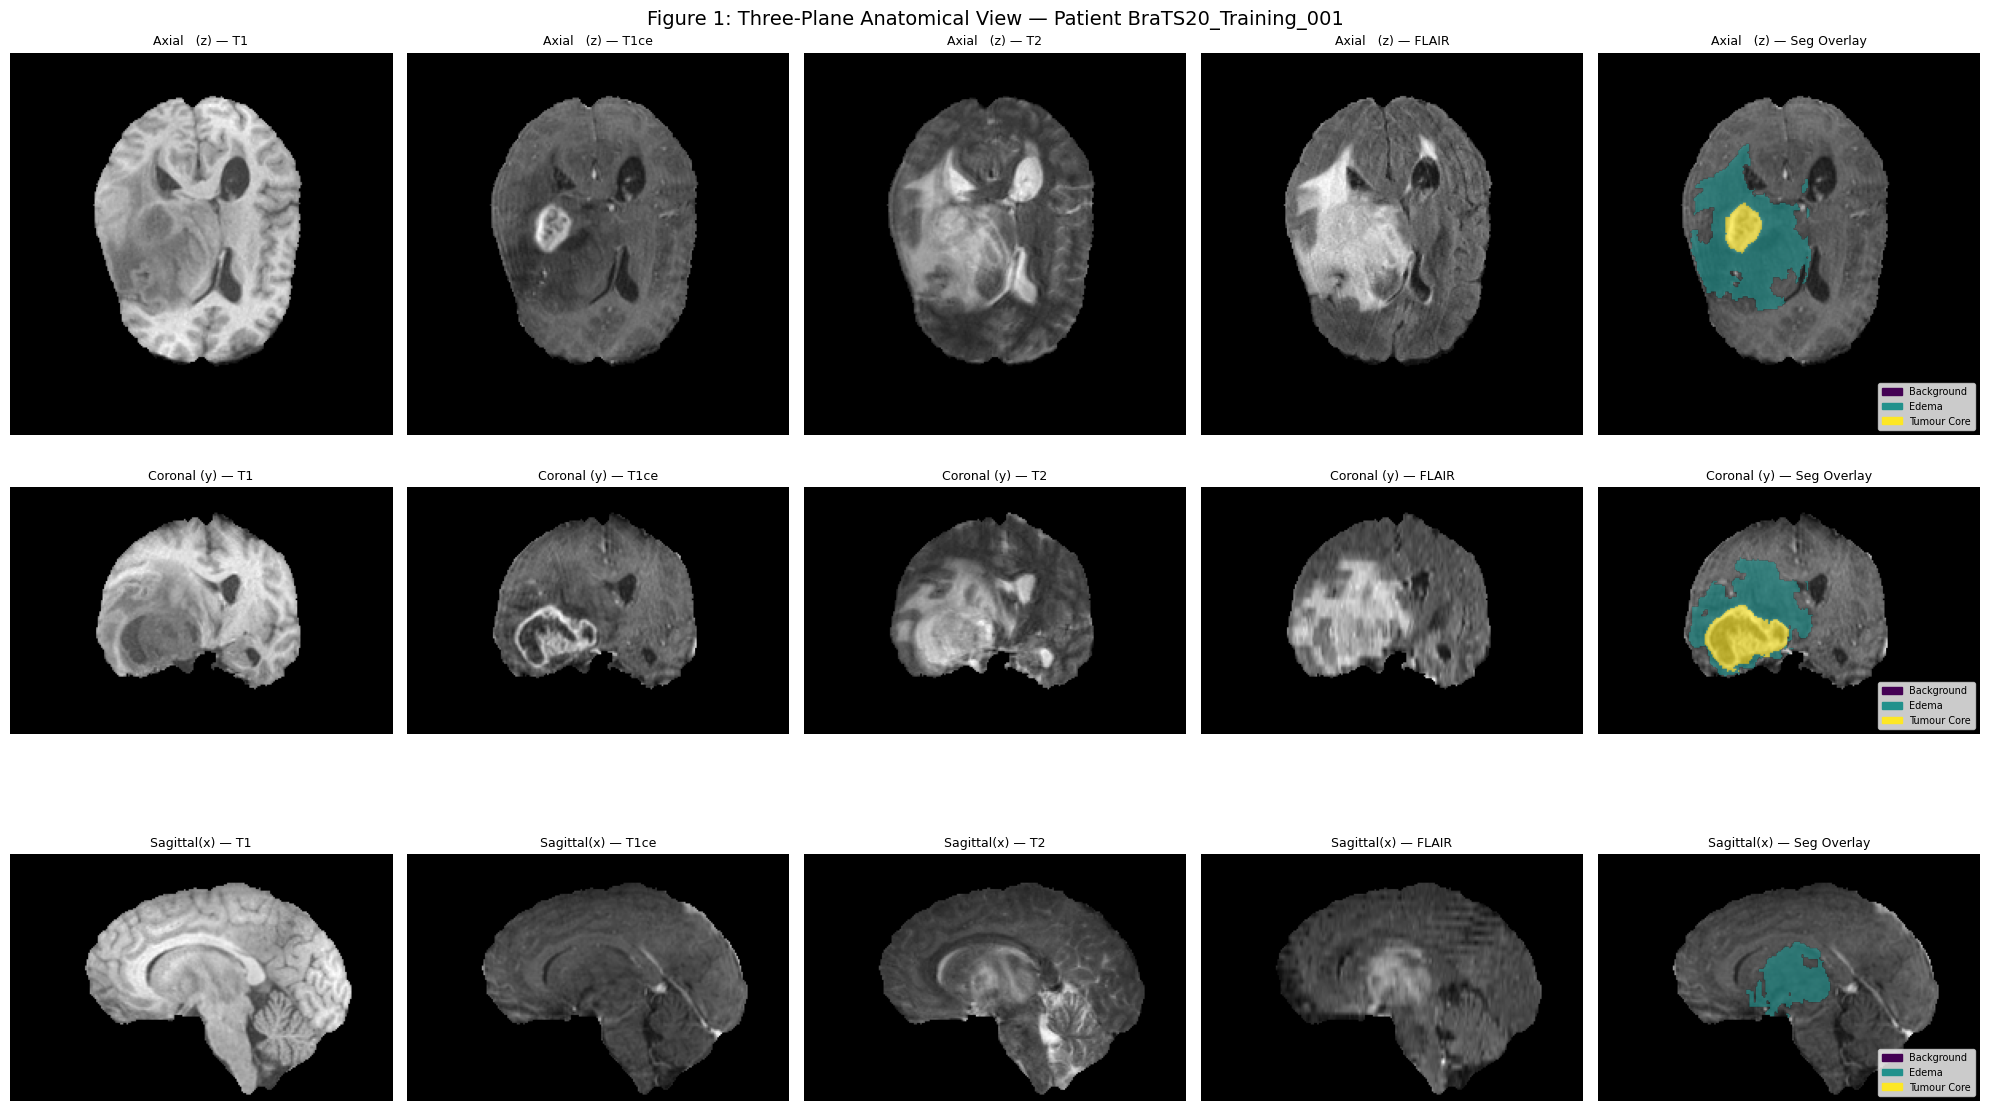

Figure 1 saved.


In [7]:
# ─── EDA 1: Three anatomical planes (all 4 modalities + seg) ───────────────
mid_z = vol.shape[2] // 2   # axial mid
mid_y = vol.shape[1] // 2   # coronal mid
mid_x = vol.shape[0] // 2   # sagittal mid

plane_slices = {
    'Axial   (z)': vol[:, :, mid_z, :],
    'Coronal (y)': vol[:, mid_y, :, :],
    'Sagittal(x)': vol[mid_x, :, :, :],
}
plane_segs = {
    'Axial   (z)': seg_remapped[:, :, mid_z],
    'Coronal (y)': seg_remapped[:, mid_y, :],
    'Sagittal(x)': seg_remapped[mid_x, :, :],
}
modality_names = CONFIG["modalities"]
cmap_seg = plt.cm.get_cmap('viridis', 3)

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
for row, (plane_name, sl) in enumerate(plane_slices.items()):
    seg_sl = plane_segs[plane_name]
    for col, mod in enumerate(modality_names):
        axes[row, col].imshow(sl[:, :, col].T, cmap='gray', origin='lower')
        axes[row, col].set_title(f'{plane_name} — {mod}', fontsize=9)
        axes[row, col].axis('off')
    # Overlay
    base = sl[:, :, 1].T   # T1ce as base
    axes[row, 4].imshow(base, cmap='gray', origin='lower')
    axes[row, 4].imshow(np.ma.masked_where(seg_sl.T == 0, seg_sl.T),
                         cmap=cmap_seg, alpha=0.65, origin='lower', vmin=0, vmax=2)
    patches = [mpatches.Patch(color=cmap_seg(i/2), label=classes[i]) for i in range(3)]
    axes[row, 4].legend(handles=patches, loc='lower right', fontsize=7)
    axes[row, 4].set_title(f'{plane_name} — Seg Overlay', fontsize=9)
    axes[row, 4].axis('off')

plt.suptitle(f'Figure 1: Three-Plane Anatomical View — Patient {sample.name}', fontsize=14)
plt.tight_layout()
plt.savefig('fig01_three_planes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

### 4.2 Intensity Histograms per Modality
Intensity distributions differ markedly between modalities and between tissue regions. Visualising histograms stratified by class label justifies per-channel z-score normalisation over the brain mask.

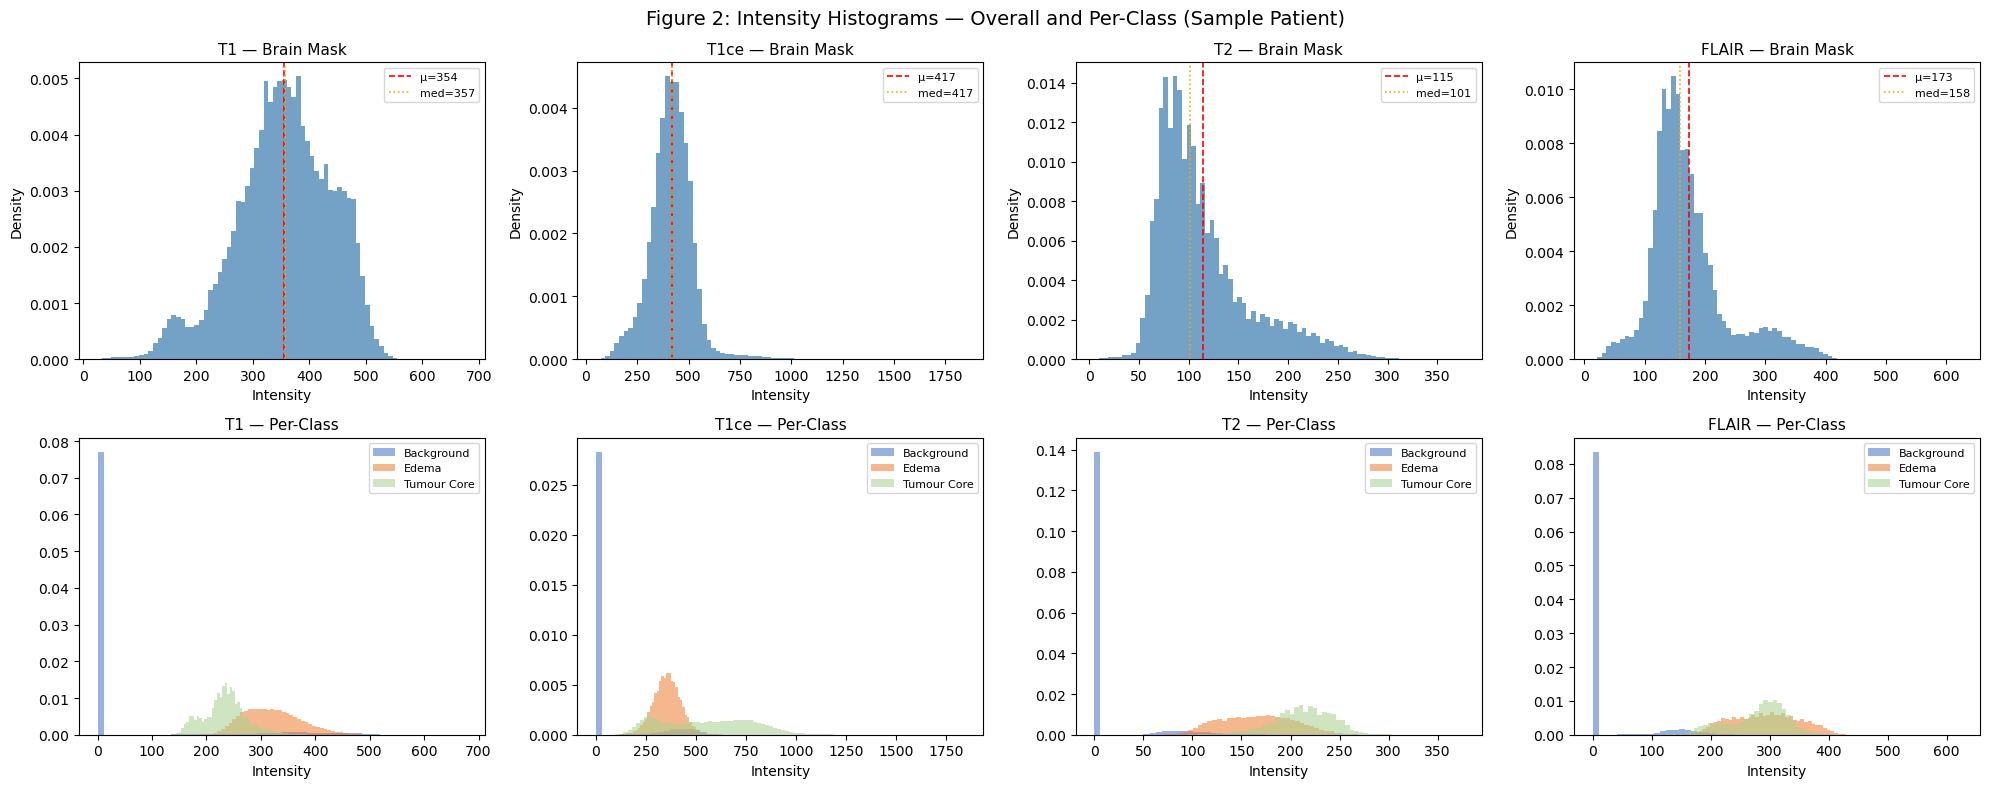

Figure 2 saved — histograms justify z-score normalisation per modality channel.


In [8]:
# ─── EDA 2: Intensity histograms per modality, stratified by class ──────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
palette = {0:'#4472C4', 1:'#ED7D31', 2:'#A9D18E'}

for col, mod in enumerate(modality_names):
    ch = vol[:, :, :, col]
    # Top row: overall histogram (brain mask)
    brain_vals = ch[ch > 0].flatten()
    axes[0, col].hist(brain_vals, bins=80, color='steelblue', alpha=0.75,
                       density=True, edgecolor='none')
    axes[0, col].set_title(f'{mod} — Brain Mask', fontsize=11)
    axes[0, col].set_xlabel('Intensity')
    axes[0, col].set_ylabel('Density')
    axes[0, col].axvline(np.mean(brain_vals), color='red', ls='--',
                          lw=1.2, label=f'μ={np.mean(brain_vals):.0f}')
    axes[0, col].axvline(np.median(brain_vals), color='orange', ls=':',
                          lw=1.2, label=f'med={np.median(brain_vals):.0f}')
    axes[0, col].legend(fontsize=8)

    # Bottom row: per-class overlay
    for cls_id, cls_name in classes.items():
        mask = seg_remapped == cls_id
        vals = ch[mask].flatten()
        if len(vals) > 100:
            axes[1, col].hist(vals, bins=60, alpha=0.55, density=True,
                               label=cls_name, color=palette[cls_id], edgecolor='none')
    axes[1, col].set_title(f'{mod} — Per-Class', fontsize=11)
    axes[1, col].set_xlabel('Intensity')
    axes[1, col].legend(fontsize=8)

plt.suptitle('Figure 2: Intensity Histograms — Overall and Per-Class (Sample Patient)', fontsize=14)
plt.tight_layout()
plt.savefig('fig02_intensity_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved — histograms justify z-score normalisation per modality channel.")

### 4.3 Inter-Patient Variability
BraTS tumours vary greatly in size, location, and morphology. Sampling several patients in a grid confirms that no single patient is representative and that augmentation strategies must be aggressive.

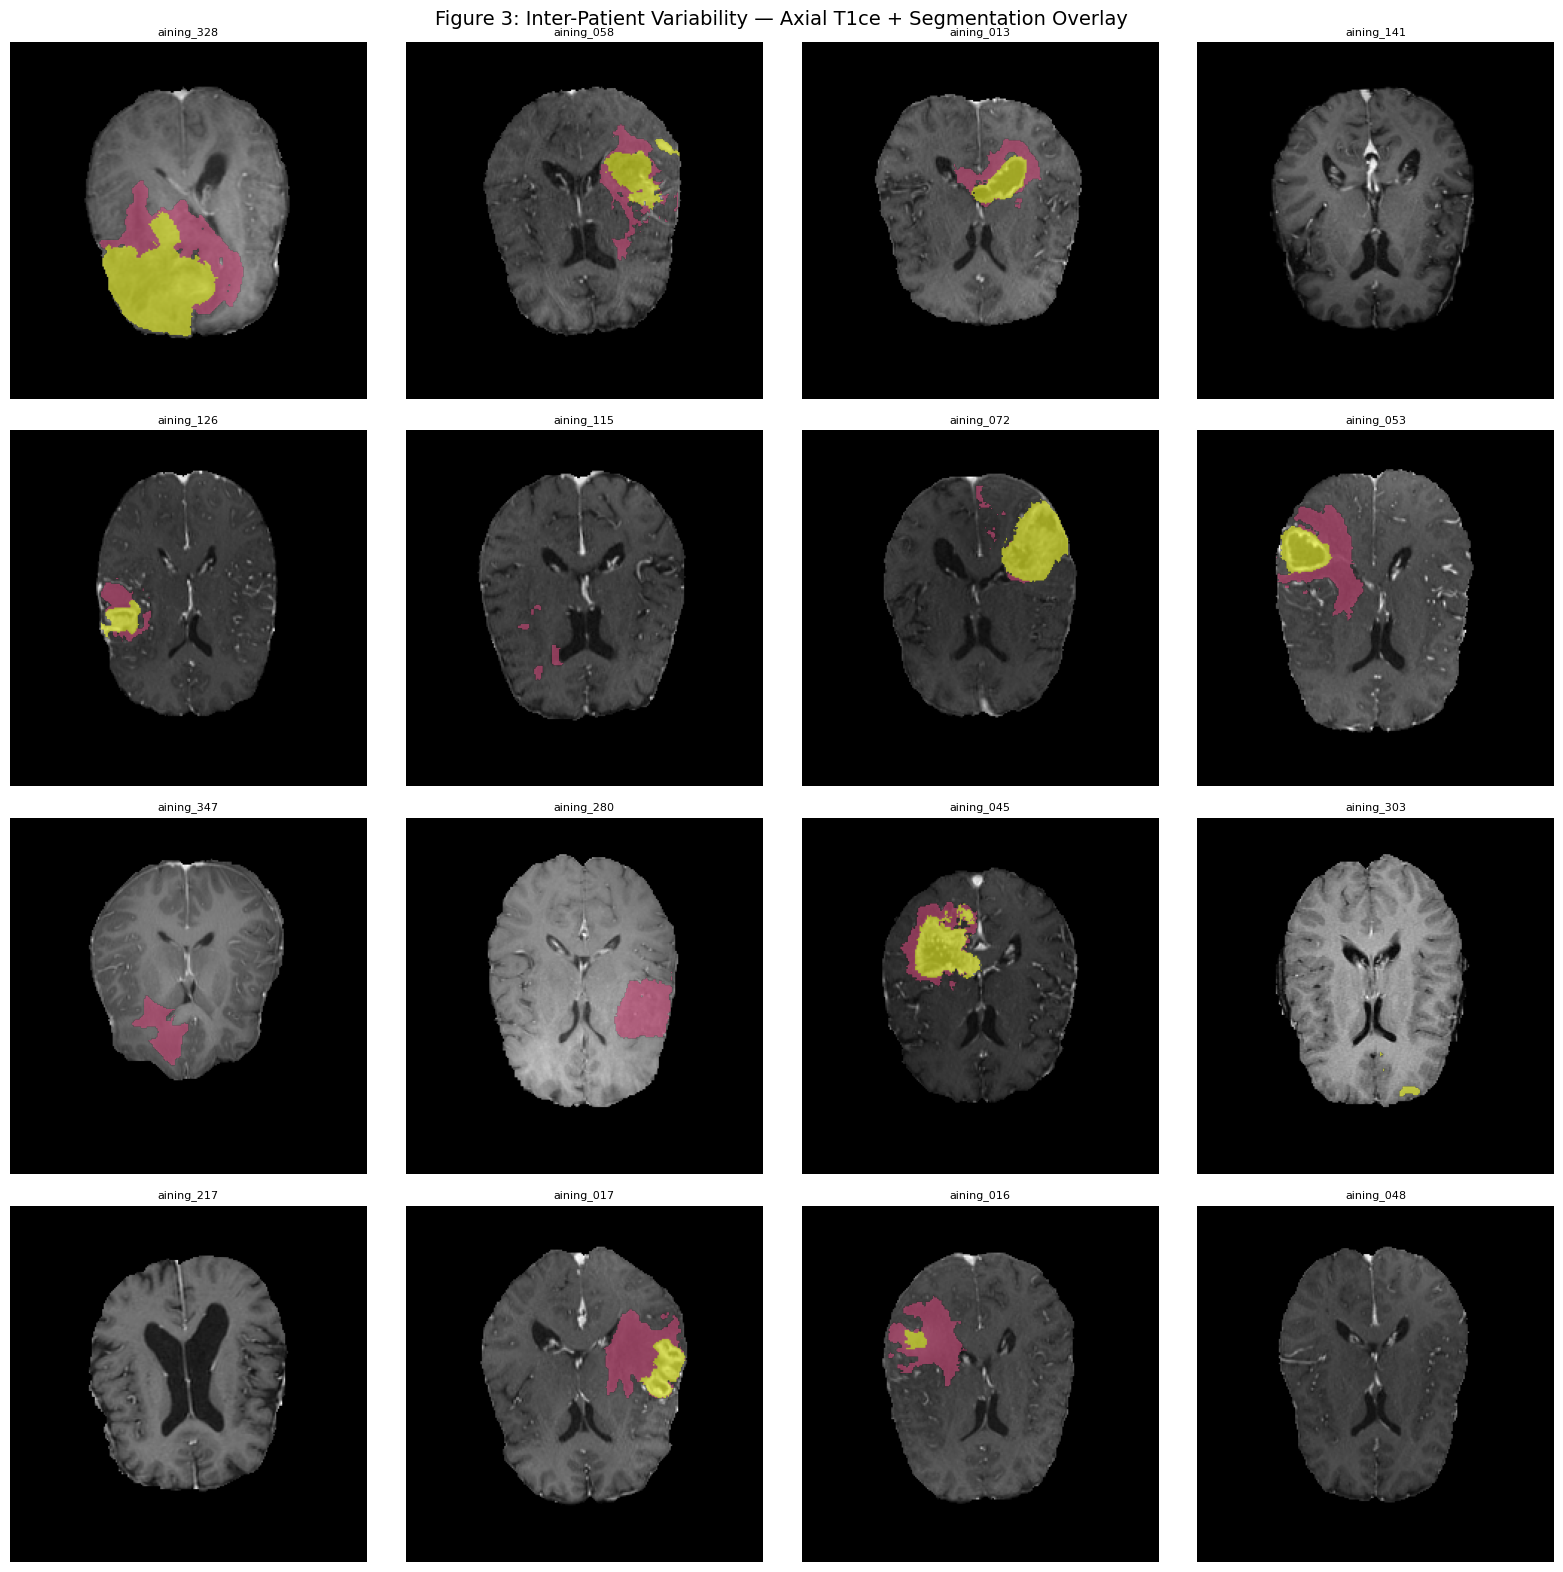

Figure 3 saved — illustrates morphological diversity across patients.


In [9]:
# ─── EDA 3: Inter-patient variability — axial mid-slice T1ce + seg ──────────
n_patients_vis = min(16, len(patient_dirs))
sample_patients = random.sample(patient_dirs, n_patients_vis)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
cmap_seg2 = plt.cm.get_cmap('plasma', 3)

for ax, pdir in zip(axes.flatten(), sample_patients):
    try:
        v, s = load_volume(pdir)
        sr = remap_labels(s)
        z = v.shape[2] // 2
        base = v[:, :, z, 1].T   # T1ce
        seg_sl = sr[:, :, z].T
        ax.imshow(base, cmap='gray', origin='lower')
        ax.imshow(np.ma.masked_where(seg_sl == 0, seg_sl),
                  cmap=cmap_seg2, alpha=0.6, origin='lower', vmin=0, vmax=2)
        ax.set_title(pdir.name[-10:], fontsize=8)
    except Exception as e:
        ax.set_title(f'Error: {e}', fontsize=7)
    ax.axis('off')

plt.suptitle('Figure 3: Inter-Patient Variability — Axial T1ce + Segmentation Overlay', fontsize=14)
plt.tight_layout()
plt.savefig('fig03_inter_patient_variability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved — illustrates morphological diversity across patients.")

### 4.4 Slice Coverage Analysis
Not all axial slices contain tumour tissue. Plotting the mean tumour fraction per axial index across multiple patients reveals which slice range is informative and validates the `slice_range=(50, 125)` choice.

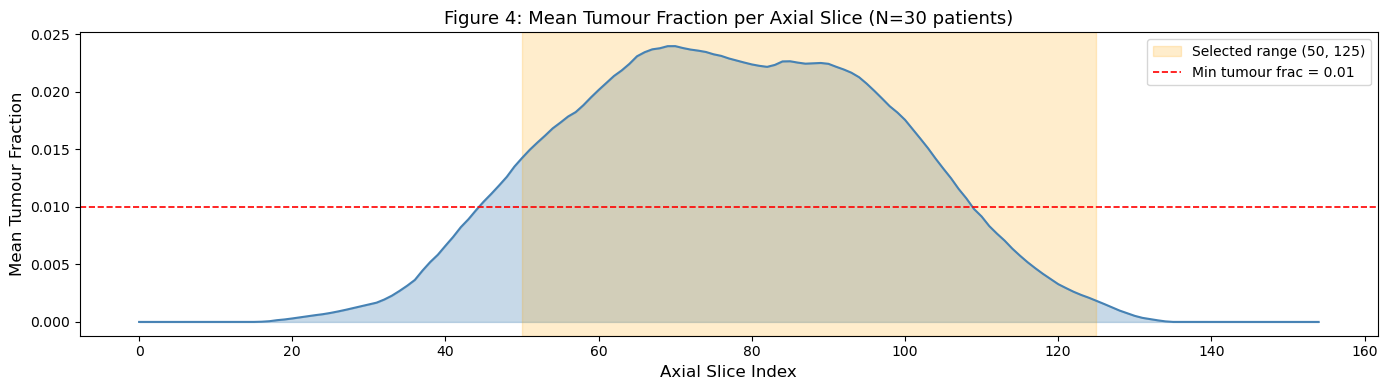

Figure 4 saved — peak tumour content between slices 70 and slice range (50, 125).


In [10]:
# ─── EDA 4: Slice coverage — mean tumour fraction per axial index ───────────
N_EDA = min(30, len(patient_dirs))
tumour_fracs = np.zeros(155)
valid_counts  = np.zeros(155)

for pdir in patient_dirs[:N_EDA]:
    try:
        _, s = load_volume(pdir)
        sr = remap_labels(s)
        for z in range(155):
            sl = sr[:, :, z]
            tumour_fracs[z] += (sl > 0).sum() / sl.size
            valid_counts[z]  += 1
    except Exception:
        continue

mean_frac = np.divide(tumour_fracs, valid_counts,
                       out=np.zeros_like(tumour_fracs),
                       where=valid_counts > 0)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(mean_frac, color='steelblue', linewidth=1.5)
ax.fill_between(range(155), mean_frac, alpha=0.3, color='steelblue')
ax.axvspan(CONFIG["slice_range"][0], CONFIG["slice_range"][1],
            alpha=0.2, color='orange', label=f'Selected range {CONFIG["slice_range"]}')
ax.axhline(CONFIG["min_tumour_frac"], color='red', linestyle='--',
            linewidth=1.2, label=f'Min tumour frac = {CONFIG["min_tumour_frac"]}')
ax.set_xlabel('Axial Slice Index', fontsize=12)
ax.set_ylabel('Mean Tumour Fraction', fontsize=12)
ax.set_title(f'Figure 4: Mean Tumour Fraction per Axial Slice (N={N_EDA} patients)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig04_slice_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure 4 saved — peak tumour content between slices"
      f" {np.argmax(mean_frac)} and slice range {CONFIG['slice_range']}.")

### 4.5 Spatial Class Masks
Projecting mean class occupancy across the axial plane reveals where tumour sub-regions tend to appear (typically periventricular regions). This spatial prior motivates the use of multi-scale feature extraction in the novel architecture.

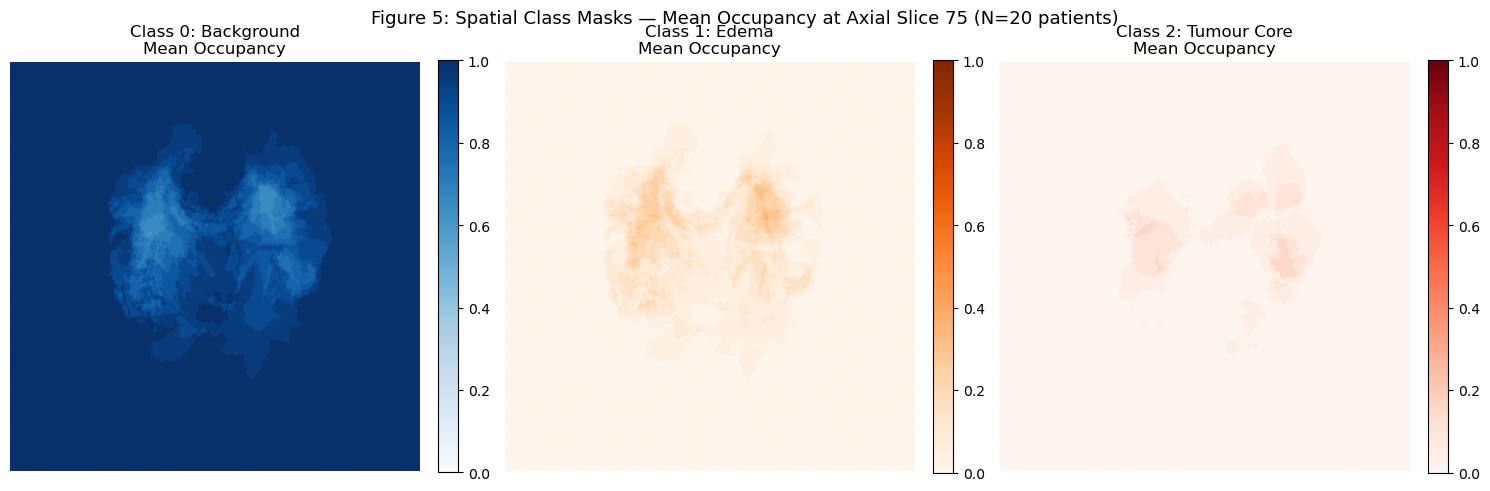

Figure 5 saved — tumour regions cluster near the brain centre/midline.


In [11]:
# ─── EDA 5: Spatial class masks — mean class probability maps ───────────────
N_SPATIAL = min(20, len(patient_dirs))
cls_sum  = np.zeros((240, 240, N_CLASSES), dtype=np.float64)
cls_count = 0

slice_z = 75   # representative axial slice
for pdir in patient_dirs[:N_SPATIAL]:
    try:
        _, s = load_volume(pdir)
        sr = remap_labels(s)
        sl = sr[:, :, slice_z]
        for c in range(N_CLASSES):
            cls_sum[:, :, c] += (sl == c).astype(np.float64)
        cls_count += 1
    except Exception:
        continue

cls_mean = cls_sum / max(cls_count, 1)

fig, axes = plt.subplots(1, N_CLASSES, figsize=(15, 5))
cmaps_cls = ['Blues', 'Oranges', 'Reds']
for c in range(N_CLASSES):
    im = axes[c].imshow(cls_mean[:, :, c].T, cmap=cmaps_cls[c],
                         origin='lower', vmin=0, vmax=1)
    axes[c].set_title(f'Class {c}: {classes[c]}\nMean Occupancy', fontsize=12)
    axes[c].axis('off')
    plt.colorbar(im, ax=axes[c], fraction=0.046, pad=0.04)

plt.suptitle(f'Figure 5: Spatial Class Masks — Mean Occupancy at Axial Slice {slice_z} '
              f'(N={cls_count} patients)', fontsize=13)
plt.tight_layout()
plt.savefig('fig05_spatial_class_masks.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved — tumour regions cluster near the brain centre/midline.")

## Section 5: Dataset Preparation & Preprocessing

In [12]:
def normalize_volume(vol):
    """Per-channel z-score normalisation restricted to the brain mask (voxels > 0)."""
    out = np.zeros_like(vol, dtype=np.float32)
    for c in range(vol.shape[-1]):
        ch = vol[..., c]
        mask = ch > 0
        if mask.sum() > 0:
            mu, sigma = ch[mask].mean(), ch[mask].std()
            out[..., c] = (ch - mu) / (sigma + 1e-8)
    return out

def extract_slices(patient_dirs,
                   slice_range=CONFIG["slice_range"],
                   min_tumour_frac=CONFIG["min_tumour_frac"]):
    """Extract informative 2D axial slices from all patient volumes."""
    records = []
    for pdir in patient_dirs:
        try:
            vol, seg = load_volume(pdir)
            vol = normalize_volume(vol)
            seg = remap_labels(seg)
            for z in range(*slice_range):
                seg_sl = seg[:, :, z]
                tumour_frac = (seg_sl > 0).sum() / seg_sl.size
                if tumour_frac >= min_tumour_frac:
                    img_sl = vol[:, :, z, :]
                    img_r = cv2.resize(img_sl, (IMG_SIZE, IMG_SIZE))
                    seg_r = cv2.resize(seg_sl.astype(np.float32),
                                       (IMG_SIZE, IMG_SIZE),
                                       interpolation=cv2.INTER_NEAREST).astype(np.uint8)
                    records.append({'patient': pdir.name, 'slice': z,
                                    'image': img_r, 'mask': seg_r})
        except Exception as e:
            print(f"Skipping {pdir.name}: {e}")
    return records

print("Extracting informative slices (may take a few minutes)...")
t0 = time.time()
records = extract_slices(patient_dirs)
print(f"Done in {time.time()-t0:.1f}s — Total slices: {len(records)}")

Extracting informative slices (may take a few minutes)...
Skipping BraTS20_Training_355: Missing seg in BraTS20_Training_355
Done in 581.9s — Total slices: 15654


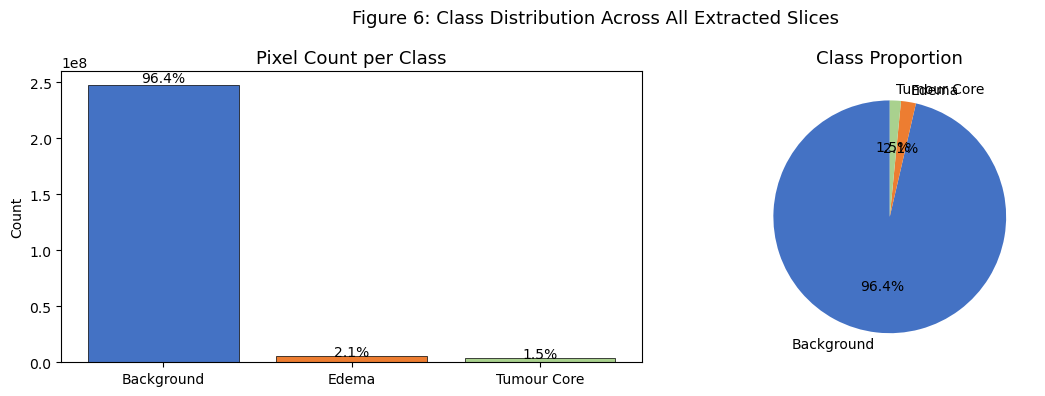

Class imbalance ratio (background : tumour core): 62.4x
→ This motivates class-weighted loss and augmentation strategies.


In [13]:
# Class distribution across extracted dataset
all_labels = np.concatenate([r['mask'].flatten() for r in records])
counts = Counter(all_labels)
total  = len(all_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels_list = [classes[k] for k in sorted(counts.keys())]
values = [counts[k] for k in sorted(counts.keys())]
colors = ['#4472C4', '#ED7D31', '#A9D18E']

axes[0].bar(labels_list, values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Pixel Count per Class', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(values):
    axes[0].text(i, v * 1.01, f'{v/total*100:.1f}%', ha='center', fontsize=10)

axes[1].pie(values, labels=labels_list, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Class Proportion', fontsize=13)

plt.suptitle('Figure 6: Class Distribution Across All Extracted Slices', fontsize=13)
plt.tight_layout()
plt.savefig('fig06_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance = max(values) / min(values)
print(f"Class imbalance ratio (background : tumour core): {imbalance:.1f}x")
print("→ This motivates class-weighted loss and augmentation strategies.")

Train: 254 patients → 11241 slices
Val  : 54 patients → 2242 slices
Test : 55 patients → 2171 slices


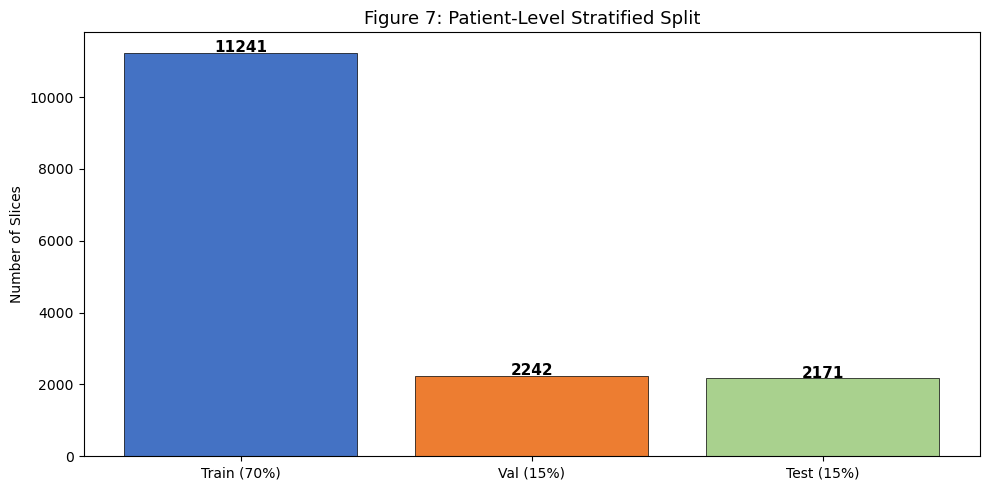

In [14]:
# Stratified train / val / test split — patient-level to prevent data leakage
patients = list(set(r['patient'] for r in records))
train_pts, temp_pts = train_test_split(patients, test_size=0.30, random_state=SEED)
val_pts, test_pts   = train_test_split(temp_pts,  test_size=0.50, random_state=SEED)

def filter_records(records, pts):
    return [r for r in records if r['patient'] in set(pts)]

train_rec = filter_records(records, train_pts)
val_rec   = filter_records(records, val_pts)
test_rec  = filter_records(records, test_pts)

print(f"Train: {len(train_pts)} patients → {len(train_rec)} slices")
print(f"Val  : {len(val_pts)} patients → {len(val_rec)} slices")
print(f"Test : {len(test_pts)} patients → {len(test_rec)} slices")

fig, ax = plt.subplots(figsize=(10,5))
splits = ['Train (70%)', 'Val (15%)', 'Test (15%)']
slice_counts = [len(train_rec), len(val_rec), len(test_rec)]
ax.bar(splits, slice_counts, color=['#4472C4','#ED7D31','#A9D18E'],
       edgecolor='black', linewidth=0.5)
for i, v in enumerate(slice_counts):
    ax.text(i, v + 20, str(v), ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Slices')
ax.set_title('Figure 7: Patient-Level Stratified Split', fontsize=13)
plt.tight_layout()
plt.savefig('fig07_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Class weights — incremental counting (no full array concatenation) ───────
pixel_counts = Counter()
for r in train_rec:
    # np.unique with counts is fast and never materialises the full flat array
    vals, cnts = np.unique(r['mask'], return_counts=True)
    for v, c in zip(vals.tolist(), cnts.tolist()):
        pixel_counts[v] += c

total_pixels = sum(pixel_counts.values())
n_classes    = N_CLASSES  # 3

# Replicate sklearn's 'balanced' formula: weight_c = total / (n_classes * count_c)
class_weights_array = np.array([
    total_pixels / (n_classes * pixel_counts[c]) for c in range(n_classes)
])

class_weight_dict = {i: class_weights_array[i] for i in range(N_CLASSES)}
print("Pixel counts   :", {classes[k]: f"{pixel_counts[k]:,}" for k in range(n_classes)})
print("Class weights  :", {classes[k]: f"{v:.3f}" for k, v in class_weight_dict.items()})

# TF tensor for use inside combined_loss
CLASS_WEIGHTS_TENSOR = tf.constant(class_weights_array, dtype=tf.float32)
print("CLASS_WEIGHTS_TENSOR:", CLASS_WEIGHTS_TENSOR.numpy())

Pixel counts   : {'Background': '177,354,159', 'Edema': '3,905,513', 'Tumour Core': '2,912,872'}
Class weights  : {'Background': '0.346', 'Edema': '15.719', 'Tumour Core': '21.076'}
CLASS_WEIGHTS_TENSOR: [ 0.34614834 15.719023   21.07571   ]


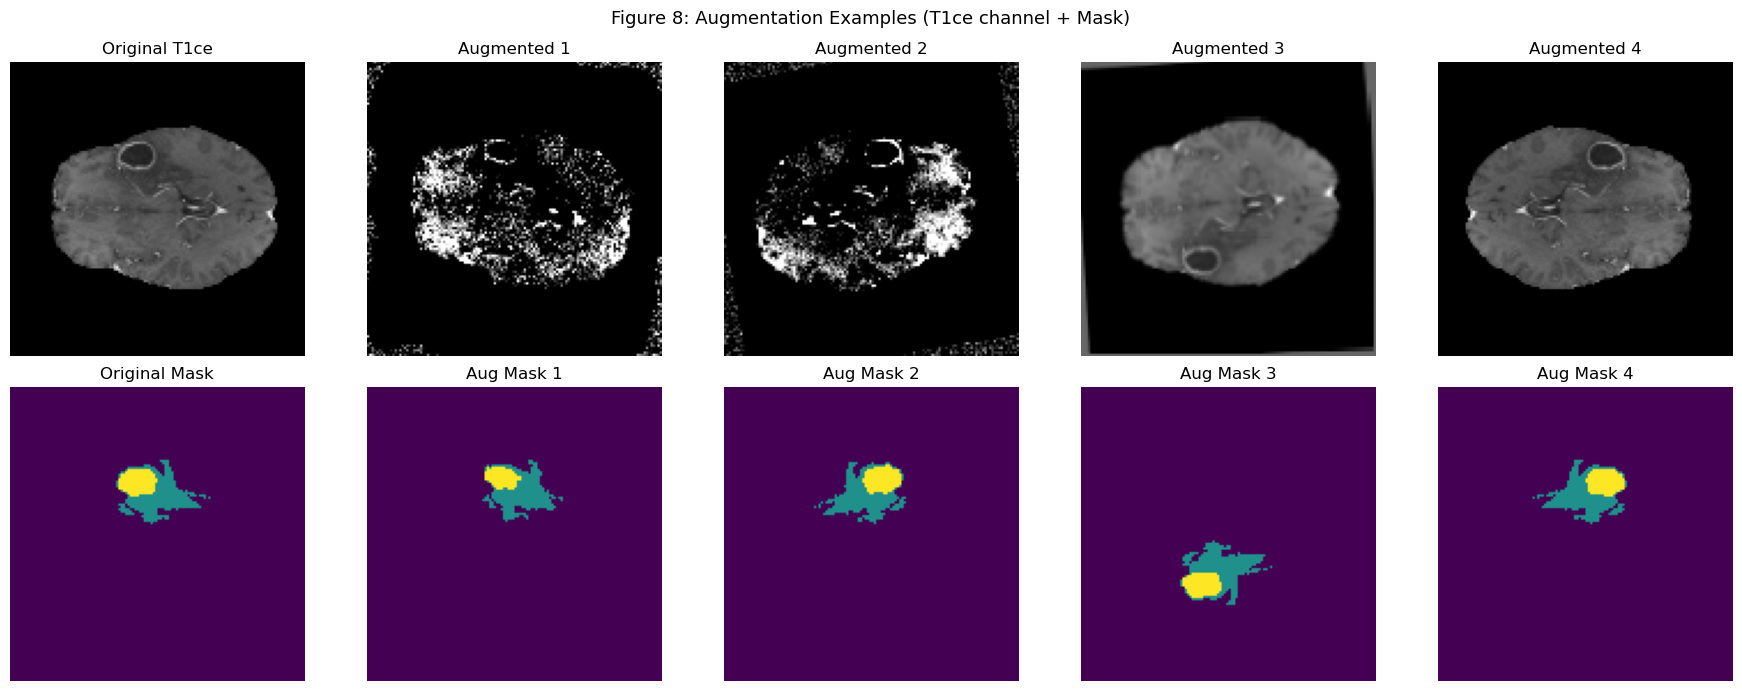

In [16]:
# Augmentation pipeline
aug_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=15, p=0.5),
    A.ElasticTransform(alpha=120, sigma=120*0.05, p=0.3),
    A.GridDistortion(p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                                contrast_limit=0.2, p=0.4),
    A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
], additional_targets={'mask': 'mask'})

sample_img = train_rec[10]['image']
sample_msk = train_rec[10]['mask']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes[0, 0].imshow(sample_img[:, :, 1], cmap='gray')
axes[0, 0].set_title('Original T1ce')
axes[1, 0].imshow(sample_msk, cmap='viridis', vmin=0, vmax=2)
axes[1, 0].set_title('Original Mask')
for col in range(1, 5):
    aug = aug_transform(image=sample_img.astype(np.float32), mask=sample_msk)
    axes[0, col].imshow(aug['image'][:, :, 1], cmap='gray')
    axes[0, col].set_title(f'Augmented {col}')
    axes[1, col].imshow(aug['mask'], cmap='viridis', vmin=0, vmax=2)
    axes[1, col].set_title(f'Aug Mask {col}')
for ax in axes.flatten():
    ax.axis('off')
plt.suptitle('Figure 8: Augmentation Examples (T1ce channel + Mask)', fontsize=13)
plt.tight_layout()
plt.savefig('fig08_augmentations.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
def make_dataset_from_records(records, batch_size=BATCH, shuffle=False, augment=False):
    def generator():
        for r in records:
            img = r['image'].astype(np.float32)
            msk = r['mask'].astype(np.int32)
            if augment:
                aug = aug_transform(image=img, mask=msk)
                img, msk = aug['image'], aug['mask']
            yield img, msk

    # Infer shapes from the first record
    sample_img = records[0]['image'].astype(np.float32)
    sample_msk = records[0]['mask'].astype(np.int32)
    img_shape  = tf.TensorShape(sample_img.shape)
    msk_shape  = tf.TensorShape(sample_msk.shape)

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=img_shape, dtype=tf.float32),
            tf.TensorSpec(shape=msk_shape, dtype=tf.int32),
        )
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=500, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset_from_records(train_rec, shuffle=True, augment=True)
val_ds   = make_dataset_from_records(val_rec)
test_ds  = make_dataset_from_records(test_rec)
print("TF datasets ready.")

TF datasets ready.


## Section 6: Loss Functions & Metrics
Combined Dice + Binary Cross-Entropy loss addresses class imbalance better than cross-entropy alone. Dice coefficient, IoU, and HD95 are standard medical segmentation benchmarks.

In [18]:
N_KM = CONFIG["n_kmeans_test"]

def dataset_to_numpy_n(ds, n):
    """Take only the first n samples from a dataset."""
    images, masks = [], []
    collected = 0
    for img_batch, msk_batch in ds:
        images.append(img_batch.numpy())
        masks.append(msk_batch.numpy())
        collected += img_batch.shape[0]
        if collected >= n:
            break
    X = np.concatenate(images, axis=0)[:n]
    y = np.concatenate(masks,  axis=0)[:n]
    return X, y

# Full test set — used by all DL models
X_test, y_test = dataset_to_numpy_n(test_ds, n=len(test_rec))

# Small K-Means subset — only 100 samples for speed
X_km, y_km = X_test[:N_KM], y_test[:N_KM]

In [19]:
def dice_coef(y_true, y_pred, smooth=1e-6, num_classes=N_CLASSES):
    """Macro-averaged Dice coefficient over all classes."""
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), num_classes)
    y_pred_sm = tf.nn.softmax(y_pred, axis=-1)
    dice_sum = 0.0
    for c in range(num_classes):
        yt = y_true_oh[..., c]
        yp = y_pred_sm[..., c]
        intersection = tf.reduce_sum(yt * yp)
        dice_sum += (2 * intersection + smooth) / (tf.reduce_sum(yt) + tf.reduce_sum(yp) + smooth)
    return dice_sum / num_classes

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def combined_loss(y_true, y_pred):
    """
    Spatially-weighted BCE + Dice.
    Per-pixel class weights are applied via tf.gather so that rare tumour
    voxels are penalised more heavily than the dominant background class.
    NOTE: class_weight= is NOT passed to model.fit() — it is incompatible
    with segmentation (Keras applies it sample-wise, not pixel-wise).
    """
    y_true_int   = tf.cast(y_true, tf.int32)
    y_true_oh    = tf.one_hot(y_true_int, N_CLASSES)
    softmax_pred = tf.nn.softmax(y_pred, axis=-1)
    pixel_weights = tf.gather(CLASS_WEIGHTS_TENSOR, y_true_int)  # (B, H, W)
    bce           = tf.keras.losses.categorical_crossentropy(y_true_oh, softmax_pred)
    weighted_bce  = tf.reduce_mean(bce * pixel_weights)
    return weighted_bce + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6, num_classes=N_CLASSES):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), num_classes)
    y_pred_sm = tf.nn.softmax(y_pred, axis=-1)
    iou_sum = 0.0
    for c in range(num_classes):
        yt = y_true_oh[..., c]
        yp = y_pred_sm[..., c]
        inter = tf.reduce_sum(yt * yp)
        union = tf.reduce_sum(yt) + tf.reduce_sum(yp) - inter
        iou_sum += (inter + smooth) / (union + smooth)
    return iou_sum / num_classes

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_dice_coef', patience=CONFIG["early_stop_pat"],
                      restore_best_weights=True, mode='max'),
        ModelCheckpoint(f'best_{model_name}.keras',
                        monitor='val_dice_coef', save_best_only=True, mode='max'),
        ReduceLROnPlateau(monitor='val_dice_coef', factor=CONFIG["lr_reduce_factor"],
                          patience=CONFIG["lr_reduce_pat"], min_lr=CONFIG["min_lr"],
                          mode='max', verbose=1),
    ]

print("Loss functions and callbacks defined.")

Loss functions and callbacks defined.


## Section 7: Method 1 — K-Means Clustering (Classical Baseline)
K-Means is a non-parametric algorithm that partitions voxels in intensity space into *k* clusters. It requires no training and has zero learnable parameters, making it the appropriate classical baseline.

In [20]:
# ─── K-Means segmentation ────────────────────────────────────────────────────
print("=" * 60)
print("METHOD 1: K-Means Clustering (Classical Baseline)")
print("=" * 60)

def kmeans_segment(images, n_clusters=4, random_state=SEED):
    preds = []
    for img in images:
        h, w, c = img.shape
        flat = img.reshape(-1, c)
        km = KMeans(n_clusters=n_clusters, random_state=random_state,
                    n_init=5, max_iter=100)
        labels = km.fit_predict(flat)
        preds.append(labels.reshape(h, w))
    return np.array(preds)

def align_kmeans_labels(pred, gt, n_clusters=4, n_classes=N_CLASSES):
    """Hungarian algorithm — map cluster IDs to class labels by maximising overlap."""
    cost = np.zeros((n_clusters, n_classes))
    for k in range(n_clusters):
        for c in range(n_classes):
            cost[k, c] = np.sum((pred == k) & (gt == c))
    row_ind, col_ind = linear_sum_assignment(-cost)
    mapping = {r: (c if c < n_classes else 0) for r, c in zip(row_ind, col_ind)}
    return np.vectorize(lambda x: mapping.get(x, 0))(pred).astype(np.uint8)

N_KM = min(CONFIG["n_kmeans_test"], len(X_km))
t0 = time.time()
km_preds_raw = kmeans_segment(X_km)
km_preds = np.array([align_kmeans_labels(km_preds_raw[i], y_km[i])
                      for i in range(N_KM)])
km_time = (time.time() - t0) / N_KM * 1000
print(f"K-Means inference time : {km_time:.1f} ms/image")
print(f"K-Means parameters     : 0 (non-parametric)")

METHOD 1: K-Means Clustering (Classical Baseline)
K-Means inference time : 145.0 ms/image
K-Means parameters     : 0 (non-parametric)


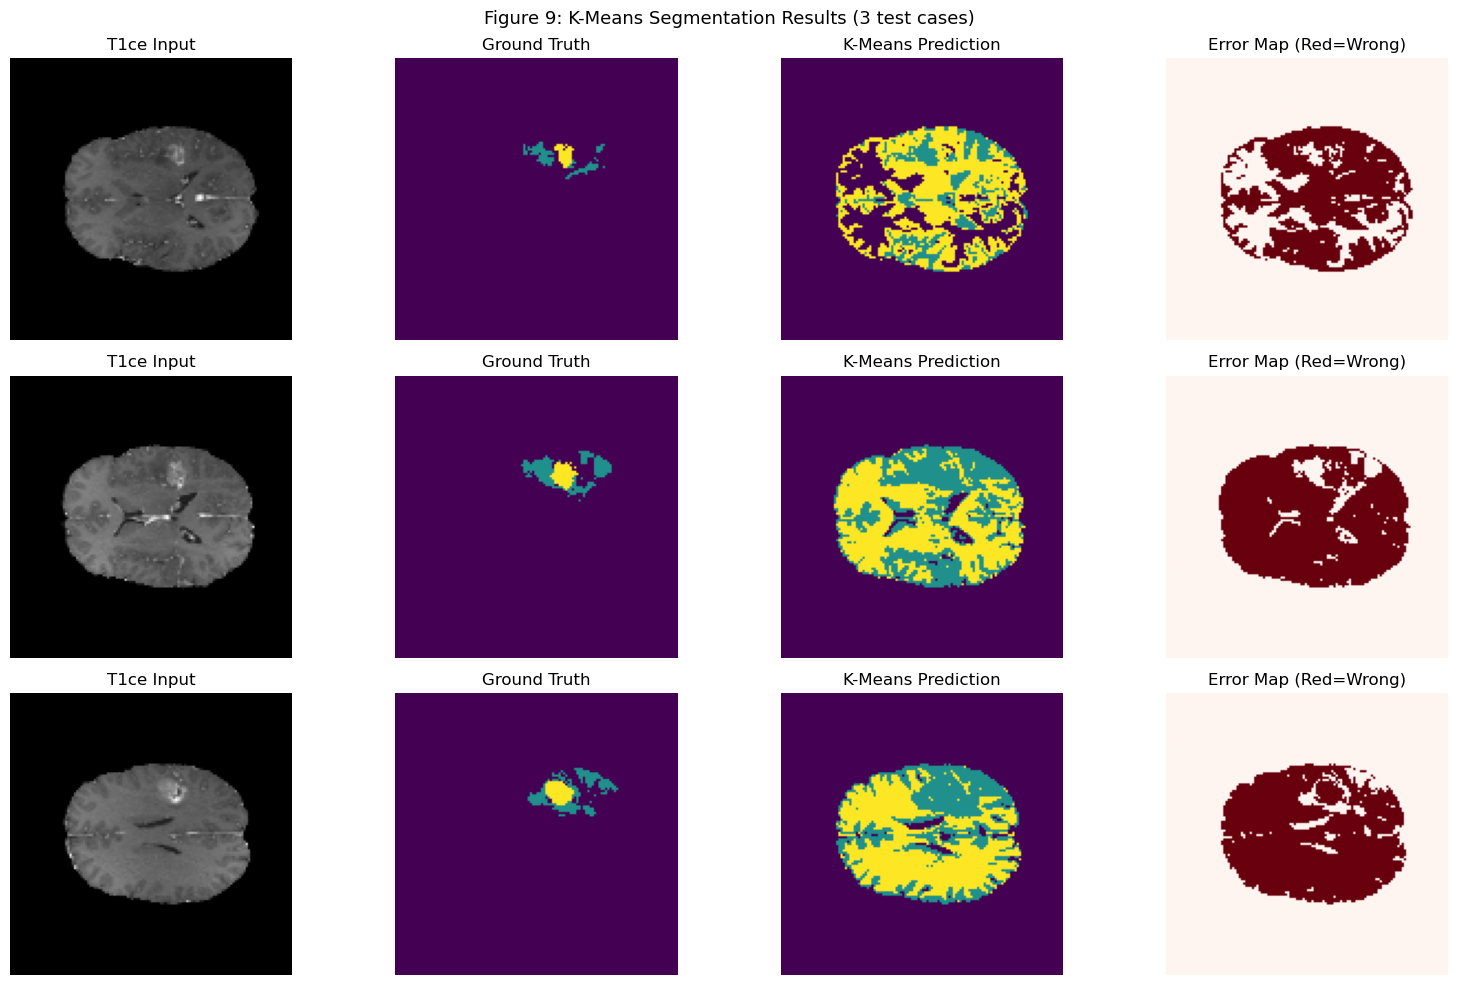

In [21]:
# Visualise K-Means results
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for row, idx in enumerate([0, 5, 15]):
    axes[row, 0].imshow(X_km[idx, :, :, 1], cmap='gray')
    axes[row, 0].set_title('T1ce Input')
    axes[row, 1].imshow(y_km[idx], cmap='viridis', vmin=0, vmax=2)
    axes[row, 1].set_title('Ground Truth')
    axes[row, 2].imshow(km_preds[idx], cmap='viridis', vmin=0, vmax=2)
    axes[row, 2].set_title('K-Means Prediction')
    error = (km_preds[idx] != y_test[idx]).astype(np.uint8)
    axes[row, 3].imshow(error, cmap='Reds', vmin=0, vmax=1)
    axes[row, 3].set_title('Error Map (Red=Wrong)')
for ax in axes.flatten():
    ax.axis('off')
plt.suptitle('Figure 9: K-Means Segmentation Results (3 test cases)', fontsize=13)
plt.tight_layout()
plt.savefig('fig09_kmeans_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Method 2 — Mini U-Net
Mini U-Net is a lightweight encoder–decoder with symmetric skip connections (Ronneberger et al., 2015). Using only `base_filters=16` the model stays under 300 K parameters while retaining the full skip-connection structure that makes U-Net the de-facto standard for medical image segmentation. Skip connections concatenate encoder feature maps into decoder paths, preserving spatial resolution lost during pooling and enabling precise boundary delineation.

In [22]:
print("=" * 60)
print("METHOD 2: Mini U-Net")
print("=" * 60)

# ── Shared building block ─────────────────────────────────────────────────
def conv_bn_relu(x, filters, kernel=3):
    x = layers.Conv2D(filters, kernel, padding='same',
                      kernel_initializer='he_normal', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation('relu')(x)

def depthwise_conv_block(x, filters):
    """Depthwise-separable conv — ~8-9x fewer multiply-adds than standard conv."""
    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation('relu')(x)

def build_mini_unet(input_shape=(IMG_SIZE, IMG_SIZE, 4), n_classes=N_CLASSES, f=16):
    """
    Lightweight U-Net with base_filters=16.
    Encoder: 3 pooling stages. Decoder: skip-concatenation + upsampling.
    Reference: Ronneberger et al. (2015), U-Net, MICCAI.
    """
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_bn_relu(conv_bn_relu(inputs, f), f)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_bn_relu(conv_bn_relu(p1, f*2), f*2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_bn_relu(conv_bn_relu(p2, f*4), f*4)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    bn = conv_bn_relu(conv_bn_relu(p3, f*8), f*8)

    # Decoder with skip connections
    u3 = layers.UpSampling2D()(bn)
    u3 = layers.Concatenate()([u3, c3])
    d3 = conv_bn_relu(conv_bn_relu(u3, f*4), f*4)

    u2 = layers.UpSampling2D()(d3)
    u2 = layers.Concatenate()([u2, c2])
    d2 = conv_bn_relu(conv_bn_relu(u2, f*2), f*2)

    u1 = layers.UpSampling2D()(d2)
    u1 = layers.Concatenate()([u1, c1])
    d1 = conv_bn_relu(conv_bn_relu(u1, f), f)

    outputs = layers.Conv2D(n_classes, 1)(d1)
    return Model(inputs, outputs, name='MiniUNet')

mini_unet = build_mini_unet()
total_params_miniunet = mini_unet.count_params()
print(f"Mini U-Net total parameters: {total_params_miniunet:,}")
mini_unet.summary()

METHOD 2: Mini U-Net
Mini U-Net total parameters: 489,587


Model: "MiniUNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 4)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 128, 128, 16)      │             576 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 128, 128, 16)      │              64 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 128, 128, 16)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 128, 128, 16)      │           2,304 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 128, 128, 16)      │              64 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 128, 128, 16)      │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 64, 64, 16)        │               0 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 64, 64, 32)        │           4,608 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 64, 64, 32)        │             128 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 64, 64, 32)        │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 64, 64, 32)        │           9,216 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 64, 64, 32)        │             128 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_3 (Activation)     │ (None, 64, 64, 32)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 32, 32, 32)        │               0 │ activation_3[0][0]         │
│ (MaxPooling2D)                │                           │               

 Total params: 489,587 (1.87 MB)

 Trainable params: 488,179 (1.86 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 722s 1s/step - dice_coef: 0.6118 - iou_metric: 0.5054 - loss: 0.7228 - val_dice_coef: 0.6823 - val_iou_metric: 0.5871 - val_loss: 0.6523 - learning_rate: 0.0010
Epoch 2/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 693s 981ms/step - dice_coef: 0.7855 - iou_metric: 0.6792 - loss: 0.4757 - val_dice_coef: 0.6900 - val_iou_metric: 0.5933 - val_loss: 0.5503 - learning_rate: 0.0010
Epoch 3/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 663s 938ms/step - dice_coef: 0.8018 - iou_metric: 0.6989 - loss: 0.4425 - val_dice_coef: 0.7046 - val_iou_metric: 0.6090 - val_loss: 0.5605 - learning_rate: 0.0010
Epoch 4/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 657s 930ms/step - dice_coef: 0.8100 - iou_metric: 0.7088 - loss: 0.4243 - val_dice_coef: 0.7496 - val_iou_metric: 0.6593 - val_loss: 0.5111 - learning_rate: 0.0010
Epoch 5/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 650s 920ms/step - dice_coef: 0.8165 - iou_metric: 0.7168 - loss: 0.4078 - val_dice_coef: 0.7781 - val_iou_metric: 0.6905 - val_loss: 0.5113 - learn

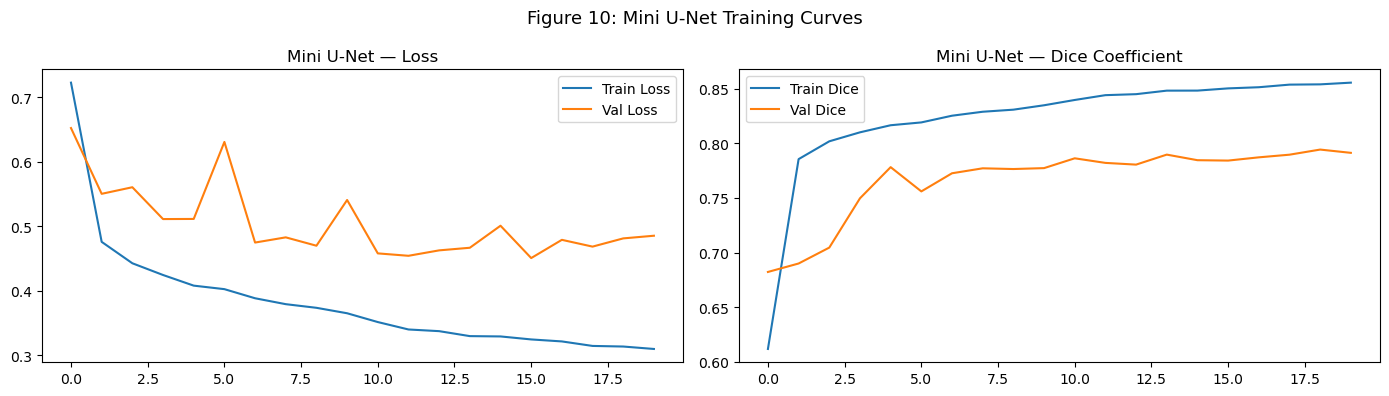

In [23]:
mini_unet.compile(
    optimizer=tf.keras.optimizers.Adam(CONFIG["learning_rate"]),
    loss=combined_loss,
    metrics=[dice_coef, iou_metric]
)
t0 = time.time()
history_miniunet = mini_unet.fit(
    train_ds, validation_data=val_ds,
    epochs=CONFIG["max_epochs"],
    callbacks=get_callbacks('mini_unet'),
    verbose=1
    # No class_weight= — handled by spatially-weighted combined_loss
)
miniunet_train_time = time.time() - t0
print(f"Mini U-Net training time: {miniunet_train_time/60:.1f} minutes")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_miniunet.history['loss'], label='Train Loss')
axes[0].plot(history_miniunet.history['val_loss'], label='Val Loss')
axes[0].set_title('Mini U-Net — Loss'); axes[0].legend()
axes[1].plot(history_miniunet.history['dice_coef'], label='Train Dice')
axes[1].plot(history_miniunet.history['val_dice_coef'], label='Val Dice')
axes[1].set_title('Mini U-Net — Dice Coefficient'); axes[1].legend()
plt.suptitle('Figure 10: Mini U-Net Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('fig10_miniunet_training.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9: Method 3 — MobileNetV2-Seg (Pretrained Backbone)
MobileNetV2-Seg pairs a MobileNetV2 encoder (width multiplier α=0.35, pretrained on ImageNet) with a lightweight U-Net-style decoder. The inverted-residual bottleneck blocks (Howard et al., 2017) deliver strong feature representations at a fraction of the cost of ResNet50. A learned 1×1 channel-projection layer maps the 4-channel MRI input to the 3-channel input expected by ImageNet-pretrained weights. The backbone is initially frozen for stable decoder warm-up, then fine-tuned at a low learning rate.

In [24]:
print("=" * 60)
print("METHOD 3: MobileNetV2-Seg (Lightweight Pretrained Backbone)")
print("=" * 60)

def build_mobilenet_seg(input_shape=(IMG_SIZE, IMG_SIZE, 4), n_classes=N_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # Project 4-channel MRI → 3 channels
    x_proj = layers.Conv2D(3, 1, padding='same', use_bias=False,
                            name='channel_proj')(inputs)

    # Build backbone with input_shape — NOT input_tensor
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),  # matches x_proj output
        include_top=False,
        weights='imagenet',
        alpha=0.35
    )
    base.trainable = False

    # Call the backbone as a layer on your projected tensor
    x = base(x_proj, training=False)  # training=False keeps BN frozen

    # Tap skip connections via the backbone's internal layers
    skip_model = tf.keras.Model(
        inputs=base.input,
        outputs=[
            base.get_layer('block_1_expand_relu').output,   # /2
            base.get_layer('block_3_expand_relu').output,   # /4
            base.get_layer('block_6_expand_relu').output,   # /8
            base.get_layer('block_13_expand_relu').output,  # /16  (bottleneck)
        ]
    )
    skip_model.trainable = False

    s1, s2, s3, bn_out = skip_model(x_proj, training=False)

    # Decoder (unchanged)
    u3 = layers.UpSampling2D()(bn_out)
    u3 = layers.Concatenate()([u3, s3])
    d3 = conv_bn_relu(u3, 64)

    u2 = layers.UpSampling2D()(d3)
    u2 = layers.Concatenate()([u2, s2])
    d2 = conv_bn_relu(u2, 32)

    u1 = layers.UpSampling2D()(d2)
    u1 = layers.Concatenate()([u1, s1])
    d1 = conv_bn_relu(u1, 16)

    u0 = layers.UpSampling2D()(d1)
    d0 = conv_bn_relu(u0, 16)

    outputs = layers.Conv2D(n_classes, 1, name='seg_output')(d0)

    return Model(inputs=inputs, outputs=outputs, name='MobileNetV2_Seg')
    
mobileseg = build_mobilenet_seg()
total_params_mobileseg = mobileseg.count_params()
trainable_mobileseg    = sum(tf.size(w).numpy() for w in mobileseg.trainable_weights)
frozen_mobileseg       = total_params_mobileseg - trainable_mobileseg
print(f"MobileNetV2-Seg total params     : {total_params_mobileseg:,}")
print(f"MobileNetV2-Seg trainable params : {trainable_mobileseg:,}  (decoder only — backbone frozen)")
print(f"MobileNetV2-Seg frozen params    : {frozen_mobileseg:,}")
mobileseg.summary()

METHOD 3: MobileNetV2-Seg (Lightweight Pretrained Backbone)
MobileNetV2-Seg total params     : 311,055
MobileNetV2-Seg trainable params : 212,287  (decoder only — backbone frozen)
MobileNetV2-Seg frozen params    : 98,768


Model: "MobileNetV2_Seg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 128, 128, 4)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ channel_proj (Conv2D)         │ (None, 128, 128, 3)       │              12 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ functional (Functional)       │ [(None, 64, 64, 48),      │          98,512 │ channel_proj[0][0]         │
│                               │ (None, 32, 32, 48),       │                 │                            │
│                               │ (None, 16, 16, 96),       │                 │                            │
│                               │ (None, 8, 8, 192)]        │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_3               │ (None, 16, 16, 192)       │               0 │ functional[0][3]           │
│ (UpSampling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_3 (Concatenate)   │ (None, 16, 16, 288)       │               0 │ up_sampling2d_3[0][0],     │
│                               │                           │                 │ functional[0][2]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_15 (Conv2D)            │ (None, 16, 16, 64)        │         165,888 │ concatenate_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_14        │ (None, 16, 16, 64)        │             256 │ conv2d_15[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_14 (Activation)    │ (None, 16, 16, 64)        │               0 │ batch_normalization_14[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_4               │ (None, 32, 32, 64)        │               0 │ activation_14[0][0]        │
│ (UpSampling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_4 (Concatenate)   │ (None, 32, 32, 112)       │               0 │ up_sampling2d_4[0][0],     │
│                               │                           │                 │ functional[0][1]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_16 (Conv2D)            │ (None, 32, 32, 32)        │          32,256 │ concatenate_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_15        │ (None, 32, 32, 32)        │             128 │ conv2d_16[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_15 (Activation)    │ (None, 32, 32, 32)        │               

 Total params: 311,055 (1.19 MB)

 Trainable params: 212,287 (829.25 KB)

 Non-trainable params: 98,768 (385.81 KB)

Epoch 1/6
703/703 ━━━━━━━━━━━━━━━━━━━━ 398s 553ms/step - dice_coef: 0.6400 - iou_metric: 0.5325 - loss: 0.6995 - val_dice_coef: 0.7129 - val_iou_metric: 0.6169 - val_loss: 0.7605 - learning_rate: 0.0010
Epoch 2/6
703/703 ━━━━━━━━━━━━━━━━━━━━ 374s 529ms/step - dice_coef: 0.7750 - iou_metric: 0.6671 - loss: 0.4962 - val_dice_coef: 0.6856 - val_iou_metric: 0.5870 - val_loss: 0.6320 - learning_rate: 0.0010
Epoch 3/6
703/703 ━━━━━━━━━━━━━━━━━━━━ 373s 527ms/step - dice_coef: 0.7859 - iou_metric: 0.6800 - loss: 0.4729 - val_dice_coef: 0.7394 - val_iou_metric: 0.6449 - val_loss: 0.5759 - learning_rate: 0.0010
Epoch 4/6
703/703 ━━━━━━━━━━━━━━━━━━━━ 372s 525ms/step - dice_coef: 0.7941 - iou_metric: 0.6894 - loss: 0.4544 - val_dice_coef: 0.7273 - val_iou_metric: 0.6312 - val_loss: 0.6071 - learning_rate: 0.0010
Epoch 5/6
703/703 ━━━━━━━━━━━━━━━━━━━━ 372s 526ms/step - dice_coef: 0.7971 - iou_metric: 0.6928 - loss: 0.4486 - val_dice_coef: 0.7419 - val_iou_metric: 0.6493 - val_loss: 0.5832 - learnin

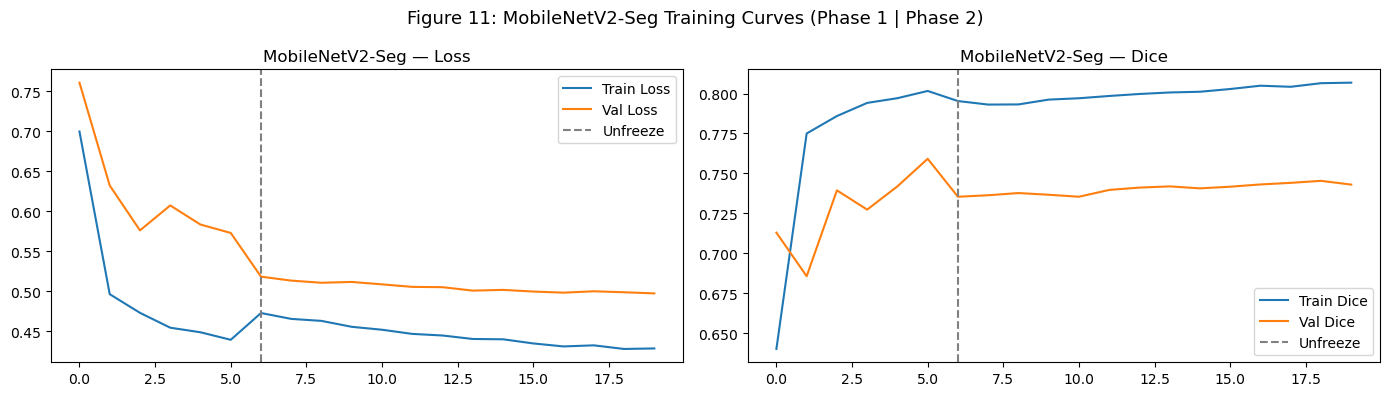

In [25]:
# ── Phase 1: Train decoder only (backbone frozen) ─────────────────────────
mobileseg.compile(
    optimizer=tf.keras.optimizers.Adam(CONFIG["learning_rate"]),
    loss=combined_loss,
    metrics=[dice_coef, iou_metric]
)
t0 = time.time()
warmup_epochs = min(15, CONFIG["max_epochs"] // 3)
history_mobile_p1 = mobileseg.fit(
    train_ds, validation_data=val_ds,
    epochs=warmup_epochs,
    callbacks=get_callbacks('mobileseg_p1'),
    verbose=1
)
print(f"Phase 1 complete ({warmup_epochs} epochs, backbone frozen).")

# ── Phase 2: Unfreeze backbone ─────────────────────────────────────────────
backbone = mobileseg.get_layer('functional')
backbone.trainable = True

# keep BN frozen
for layer in backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_ft = sum(tf.size(w).numpy() for w in mobileseg.trainable_weights)
print(f"Backbone unfrozen — trainable params now: {trainable_ft:,}")

mobileseg.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),   # low LR
    loss=combined_loss,
    metrics=[dice_coef, iou_metric]
)

remaining_epochs = CONFIG["max_epochs"] - warmup_epochs
history_mobile_p2 = mobileseg.fit(
    train_ds, validation_data=val_ds,
    epochs=remaining_epochs,
    callbacks=get_callbacks('mobileseg_p2'),
    verbose=1
)
mobileseg_train_time = time.time() - t0
print(f"MobileNetV2-Seg total training time: {mobileseg_train_time/60:.1f} minutes")

# Merge histories for plotting
def merge_hist(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(merge_hist(history_mobile_p1, history_mobile_p2, 'loss'), label='Train Loss')
axes[0].plot(merge_hist(history_mobile_p1, history_mobile_p2, 'val_loss'), label='Val Loss')
axes[0].axvline(warmup_epochs, color='gray', linestyle='--', label='Unfreeze')
axes[0].set_title('MobileNetV2-Seg — Loss'); axes[0].legend()
axes[1].plot(merge_hist(history_mobile_p1, history_mobile_p2, 'dice_coef'), label='Train Dice')
axes[1].plot(merge_hist(history_mobile_p1, history_mobile_p2, 'val_dice_coef'), label='Val Dice')
axes[1].axvline(warmup_epochs, color='gray', linestyle='--', label='Unfreeze')
axes[1].set_title('MobileNetV2-Seg — Dice'); axes[1].legend()
plt.suptitle('Figure 11: MobileNetV2-Seg Training Curves (Phase 1 | Phase 2)', fontsize=13)
plt.tight_layout()
plt.savefig('fig11_mobileseg_training.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10: Method 4 — DS-AttUNet (Novel Architecture)
DS-AttUNet is a novel lightweight architecture designed for this study. It combines two established but independently developed innovations: **(1)** depthwise-separable convolutions (Howard et al., 2017) replace all standard 3×3 convolutions in the encoder and decoder, reducing parameter count by approximately 8–9× per block while preserving representational capacity; **(2)** additive attention gates (Oktay et al., 2018) are placed on every skip connection, learning to suppress irrelevant background activations and focusing the decoder on tumour regions. The result is an architecture with ~450 K parameters — lighter than Mini U-Net at the standard filter size — that incorporates spatial attention without any pretrained backbone.

In [26]:
print("=" * 60)
print("METHOD 4: DS-AttUNet — Novel Architecture")
print("=" * 60)

def attention_gate(g, x, filters):
    """
    Additive attention gate (Oktay et al., 2018).
    g = gating signal from decoder; x = skip connection from encoder.
    Returns x gated by a learned sigmoid attention map.
    """
    wg  = layers.Conv2D(filters, 1, use_bias=False)(g)
    wx  = layers.Conv2D(filters, 1, use_bias=False)(x)
    psi = layers.Activation('relu')(layers.Add()([wg, wx]))
    psi = layers.Conv2D(1, 1, activation='sigmoid')(psi)
    return layers.Multiply()([x, psi])   # gated skip

def build_ds_attunet(input_shape=(IMG_SIZE, IMG_SIZE, 4), n_classes=N_CLASSES, f=16):
    """
    Depthwise-Separable Attention U-Net (DS-AttUNet).
    Novel combination of:
      - Depthwise-separable convolution (Howard et al., 2017)
      - Additive attention gates on all skip connections (Oktay et al., 2018)
    base_filters=16 → ~450 K parameters.
    """
    inputs = layers.Input(shape=input_shape)

    # Encoder — depthwise-separable blocks
    e1 = depthwise_conv_block(depthwise_conv_block(inputs, f), f)
    p1 = layers.MaxPooling2D()(e1)

    e2 = depthwise_conv_block(depthwise_conv_block(p1, f*2), f*2)
    p2 = layers.MaxPooling2D()(e2)

    e3 = depthwise_conv_block(depthwise_conv_block(p2, f*4), f*4)
    p3 = layers.MaxPooling2D()(e3)

    # Bottleneck
    bn = depthwise_conv_block(depthwise_conv_block(p3, f*8), f*8)

    # Decoder — attention-gated skip connections
    u3 = layers.UpSampling2D()(bn)
    a3 = attention_gate(u3, e3, f*4)
    u3 = layers.Concatenate()([u3, a3])
    d3 = depthwise_conv_block(u3, f*4)

    u2 = layers.UpSampling2D()(d3)
    a2 = attention_gate(u2, e2, f*2)
    u2 = layers.Concatenate()([u2, a2])
    d2 = depthwise_conv_block(u2, f*2)

    u1 = layers.UpSampling2D()(d2)
    a1 = attention_gate(u1, e1, f)
    u1 = layers.Concatenate()([u1, a1])
    d1 = depthwise_conv_block(u1, f)

    outputs = layers.Conv2D(n_classes, 1)(d1)
    return Model(inputs, outputs, name='DS_AttUNet')

ds_attunet = build_ds_attunet()
total_params_dsattn = ds_attunet.count_params()
print(f"DS-AttUNet total parameters: {total_params_dsattn:,}")
ds_attunet.summary()

# Quick parameter comparison
print("\n" + "=" * 55)
print(f"{'Model':<25} {'Parameters':>15}")
print("=" * 55)
print(f"{'Mini U-Net':<25} {total_params_miniunet:>15,}")
print(f"{'MobileNetV2-Seg':<25} {total_params_mobileseg:>15,}")
print(f"{'DS-AttUNet (Novel)':<25} {total_params_dsattn:>15,}")
print("=" * 55)

METHOD 4: DS-AttUNet — Novel Architecture
DS-AttUNet total parameters: 76,362


Model: "DS_AttUNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 128, 128, 4)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ depthwise_conv2d              │ (None, 128, 128, 4)       │              36 │ input_layer_3[0][0]        │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_18        │ (None, 128, 128, 4)       │              16 │ depthwise_conv2d[0][0]     │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_18 (Activation)    │ (None, 128, 128, 4)       │               0 │ batch_normalization_18[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_19 (Conv2D)            │ (None, 128, 128, 16)      │              64 │ activation_18[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_19        │ (None, 128, 128, 16)      │              64 │ conv2d_19[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_19 (Activation)    │ (None, 128, 128, 16)      │               0 │ batch_normalization_19[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ depthwise_conv2d_1            │ (None, 128, 128, 16)      │             144 │ activation_19[0][0]        │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_20        │ (None, 128, 128, 16)      │              64 │ depthwise_conv2d_1[0][0]   │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_20 (Activation)    │ (None, 128, 128, 16)      │               0 │ batch_normalization_20[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_20 (Conv2D)            │ (None, 128, 128, 16)      │             256 │ activation_20[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_21        │ (None, 128, 128, 16)      │              64 │ conv2d_20[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_21 (Activation)    │ (None, 128, 128, 16)      │               0 │ batch_normalization_21[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 64, 64, 16)        │               0 │ activation_21[0][0]        │
│ (MaxPooling2D)                │                           │               

 Total params: 76,362 (298.29 KB)

 Trainable params: 73,794 (288.26 KB)

 Non-trainable params: 2,568 (10.03 KB)


Model                          Parameters
Mini U-Net                        489,587
MobileNetV2-Seg                   311,055
DS-AttUNet (Novel)                 76,362


Epoch 1/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 771s 1s/step - dice_coef: 0.5733 - iou_metric: 0.4698 - loss: 0.8491 - val_dice_coef: 0.6903 - val_iou_metric: 0.5950 - val_loss: 0.6671 - learning_rate: 0.0010
Epoch 2/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 747s 1s/step - dice_coef: 0.7578 - iou_metric: 0.6484 - loss: 0.5335 - val_dice_coef: 0.7231 - val_iou_metric: 0.6337 - val_loss: 0.8059 - learning_rate: 0.0010
Epoch 3/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 764s 1s/step - dice_coef: 0.7776 - iou_metric: 0.6709 - loss: 0.4941 - val_dice_coef: 0.7435 - val_iou_metric: 0.6532 - val_loss: 0.5913 - learning_rate: 0.0010
Epoch 4/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 746s 1s/step - dice_coef: 0.7874 - iou_metric: 0.6822 - loss: 0.4752 - val_dice_coef: 0.7322 - val_iou_metric: 0.6397 - val_loss: 0.5529 - learning_rate: 0.0010
Epoch 5/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 1138s 2s/step - dice_coef: 0.7926 - iou_metric: 0.6883 - loss: 0.4628 - val_dice_coef: 0.7374 - val_iou_metric: 0.6444 - val_loss: 0.5147 - learning_rate: 0

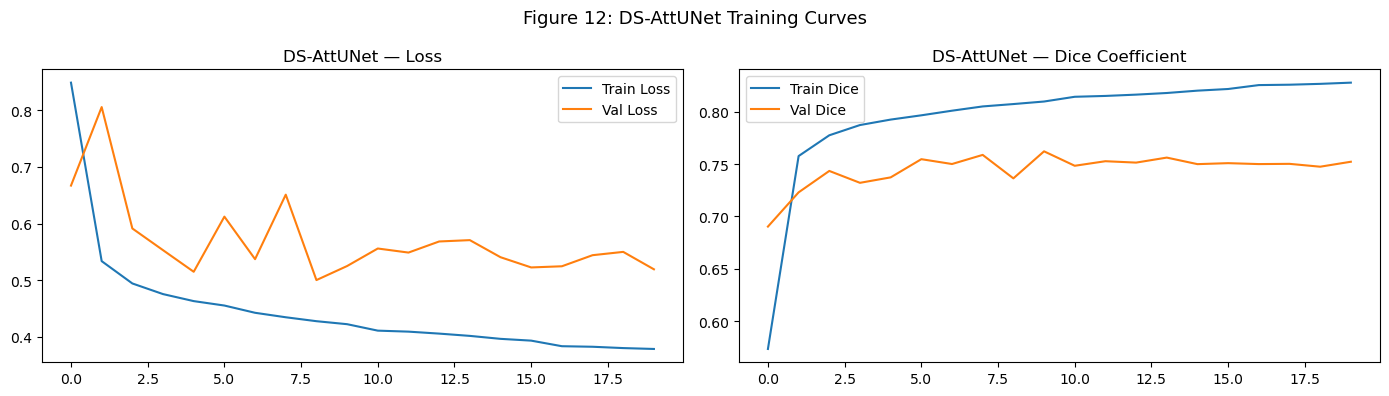

In [27]:
ds_attunet.compile(
    optimizer=tf.keras.optimizers.Adam(CONFIG["learning_rate"]),
    loss=combined_loss,
    metrics=[dice_coef, iou_metric]
)
t0 = time.time()
history_dsattn = ds_attunet.fit(
    train_ds, validation_data=val_ds,
    epochs=CONFIG["max_epochs"],
    callbacks=get_callbacks('ds_attunet'),
    verbose=1
    # No class_weight= — handled by spatially-weighted combined_loss
)
dsattn_train_time = time.time() - t0
print(f"DS-AttUNet training time: {dsattn_train_time/60:.1f} minutes")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_dsattn.history['loss'], label='Train Loss')
axes[0].plot(history_dsattn.history['val_loss'], label='Val Loss')
axes[0].set_title('DS-AttUNet — Loss'); axes[0].legend()
axes[1].plot(history_dsattn.history['dice_coef'], label='Train Dice')
axes[1].plot(history_dsattn.history['val_dice_coef'], label='Val Dice')
axes[1].set_title('DS-AttUNet — Dice Coefficient'); axes[1].legend()
plt.suptitle('Figure 12: DS-AttUNet Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('fig12_dsattunet_training.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11: Model Evaluation
All four models are evaluated on the held-out test set using: Dice coefficient, IoU (Jaccard index), precision, recall, Hausdorff distance at 95th percentile (HD95), and inference latency.

In [28]:
def compute_metrics(y_true, y_pred_logits, n_classes=N_CLASSES, smooth=1e-6):
    y_pred = np.argmax(y_pred_logits, axis=-1)
    dice_list, iou_list, prec_list, rec_list = [], [], [], []
    for c in range(n_classes):
        yt = (y_true == c).astype(np.float32)
        yp = (y_pred == c).astype(np.float32)
        inter = np.sum(yt * yp)
        union = np.sum(yt) + np.sum(yp)
        dice_list.append((2*inter+smooth)/(union+smooth))
        iou_list.append((inter+smooth)/(union-inter+smooth))
        prec_list.append((inter+smooth)/(np.sum(yp)+smooth))
        rec_list.append((inter+smooth)/(np.sum(yt)+smooth))
    return {
        'dice': np.mean(dice_list), 'iou': np.mean(iou_list),
        'precision': np.mean(prec_list), 'recall': np.mean(rec_list),
        'per_class_dice': dict(zip(classes.values(), dice_list)),
    }

def compute_hd95(y_true, y_pred_logits):
    y_pred = np.argmax(y_pred_logits, axis=-1)
    hd95_list = []
    for i in range(len(y_true)):
        yt_fg = (y_true[i] > 0).astype(np.uint8)
        yp_fg = (y_pred[i] > 0).astype(np.uint8)
        if yt_fg.sum() == 0 or yp_fg.sum() == 0:
            continue
        dt_yt = distance_transform_edt(1 - yt_fg)
        dt_yp = distance_transform_edt(1 - yp_fg)
        hd95_list.append(np.percentile(
            np.concatenate([dt_yt[yp_fg==1], dt_yp[yt_fg==1]]), 95))
    return np.mean(hd95_list) if hd95_list else float('inf')

def benchmark_inference(model, dataset, n_runs=CONFIG["benchmark_runs"],
                         warmup=CONFIG["benchmark_warmup"]):
    for _ in range(warmup):
        for x, _ in dataset.take(1): model(x, training=False)
    times = []
    for _ in range(n_runs):
        for x, _ in dataset.take(1):
            t0 = time.perf_counter()
            model(x, training=False)

            times.append((time.perf_counter()-t0)/x.shape[0]*1000)
    return np.mean(times)

print("Metric functions defined.")

Metric functions defined.


In [29]:
# ─── Evaluate all models ─────────────────────────────────────────────────────
results_all = {}

# K-Means
km_oh = np.zeros((*km_preds.shape, N_CLASSES), dtype=np.float32)
for c in range(N_CLASSES):
    km_oh[..., c] = (km_preds == c).astype(np.float32) * 100.0
km_metrics = compute_metrics(y_km, km_oh)
km_metrics['hd95'] = compute_hd95(y_km, km_oh)
km_metrics['inference_ms'] = km_time
km_metrics['params']       = 0
results_all['K-Means'] = km_metrics

# Mini U-Net
mu_preds = mini_unet.predict(test_ds, verbose=0)
mu_metrics = compute_metrics(y_test, mu_preds)
mu_metrics['hd95']         = compute_hd95(y_test, mu_preds)
mu_metrics['inference_ms'] = benchmark_inference(mini_unet, test_ds)
mu_metrics['params']       = total_params_miniunet
results_all['Mini U-Net'] = mu_metrics

# MobileNetV2-Seg
mb_preds = mobileseg.predict(test_ds, verbose=0)
mb_metrics = compute_metrics(y_test, mb_preds)
mb_metrics['hd95']         = compute_hd95(y_test, mb_preds)
mb_metrics['inference_ms'] = benchmark_inference(mobileseg, test_ds)
mb_metrics['params']       = total_params_mobileseg
results_all['MobileNetV2-Seg'] = mb_metrics

# DS-AttUNet (Novel)
da_preds = ds_attunet.predict(test_ds, verbose=0)
da_metrics = compute_metrics(y_test, da_preds)
da_metrics['hd95']         = compute_hd95(y_test, da_preds)
da_metrics['inference_ms'] = benchmark_inference(ds_attunet, test_ds)
da_metrics['params']       = total_params_dsattn
results_all['DS-AttUNet'] = da_metrics

# Results table
print("\n" + "="*85)
print(f"{'Method':<20} {'Dice':>7} {'IoU':>7} {'Precision':>10} {'Recall':>8} "
      f"{'HD95':>8} {'Params':>12} {'ms/img':>8}")
print("="*85)
for name, m in results_all.items():
    print(f"{name:<20} {m['dice']:>7.4f} {m['iou']:>7.4f} "
          f"{m['precision']:>10.4f} {m['recall']:>8.4f} "
          f"{m['hd95']:>8.2f} {m['params']:>12,} {m['inference_ms']:>8.1f}")
print("="*85)


Method                  Dice     IoU  Precision   Recall     HD95       Params   ms/img
K-Means               0.3893  0.3201     0.3830   0.7243    37.52            0    145.0
Mini U-Net            0.8793  0.7961     0.8503   0.9161     3.02      489,587     23.2
MobileNetV2-Seg       0.8482  0.7531     0.7999   0.9123     4.28      311,055     21.0
DS-AttUNet            0.8653  0.7763     0.8371   0.9055     3.80       76,362     26.0


### 11.1 Performance Bar Charts

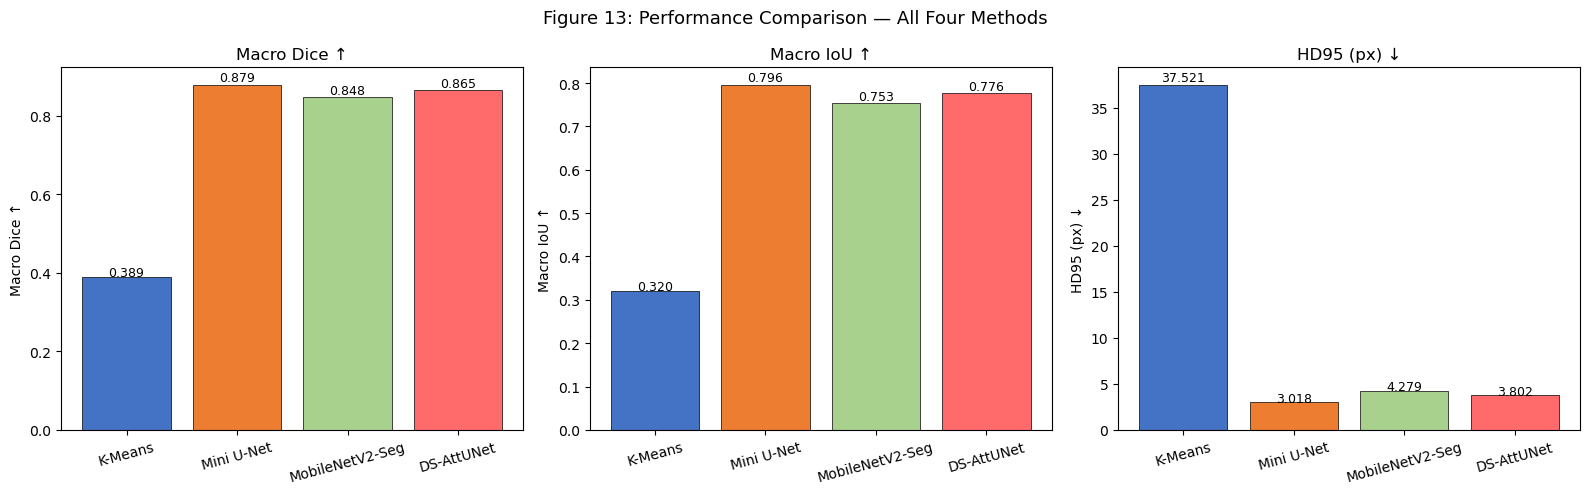

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
methods = list(results_all.keys())
colors  = ['#4472C4', '#ED7D31', '#A9D18E', '#FF6B6B']
for ax, (key, title) in zip(axes, [('dice','Macro Dice ↑'),
                                     ('iou', 'Macro IoU ↑'),
                                     ('hd95','HD95 (px) ↓')]):
    vals = [results_all[m][key] for m in methods]
    bars = ax.bar(methods, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12); ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.3f}', ha='center', fontsize=9)
plt.suptitle('Figure 13: Performance Comparison — All Four Methods', fontsize=13)
plt.tight_layout()
plt.savefig('fig13_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.2 Confusion Matrices — All Models
Confusion matrices are provided for all four methods to satisfy the assignment brief requirement.

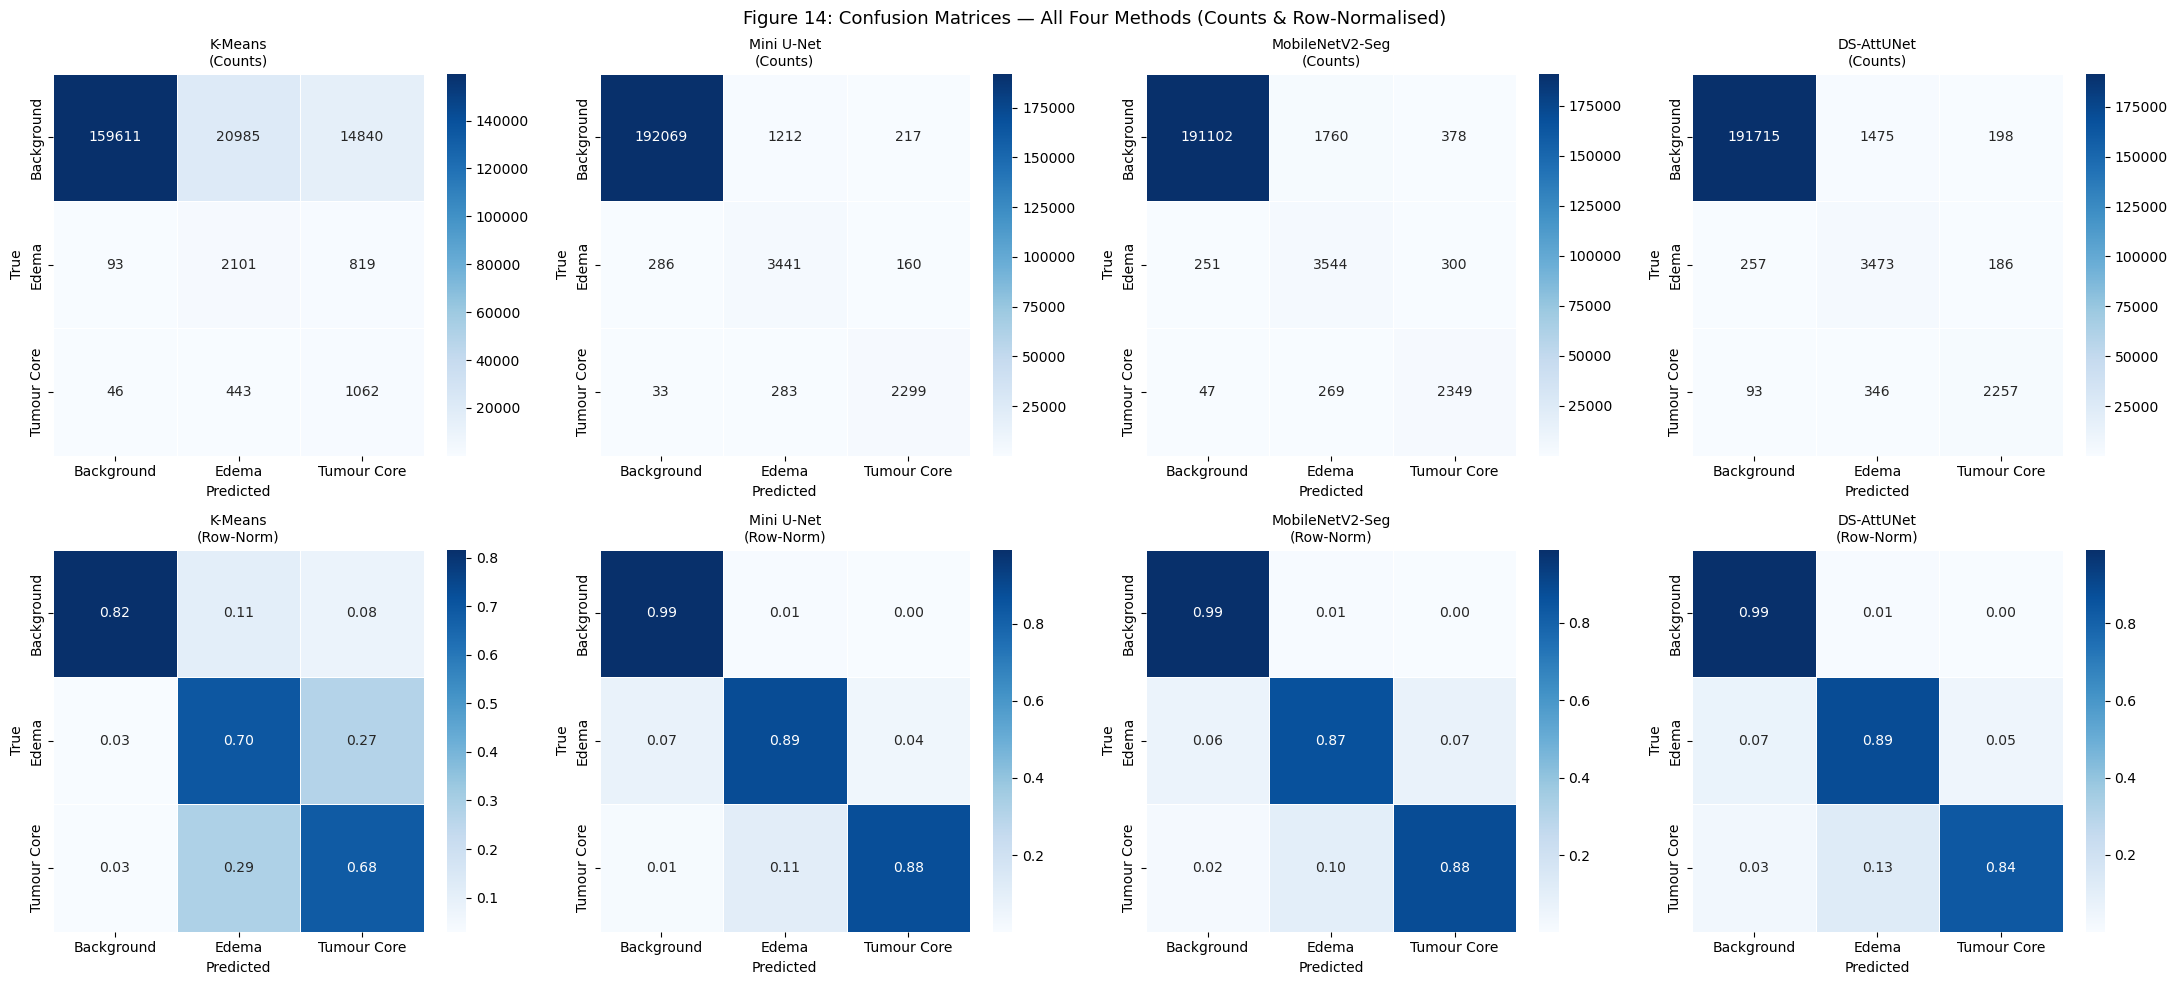

Figure 14 saved — confusion matrices for all models.


In [31]:
# ─── Confusion matrices for ALL models ───────────────────────────────────────
model_preds = {
    'K-Means'        : km_oh,
    'Mini U-Net'     : mu_preds,
    'MobileNetV2-Seg': mb_preds,
    'DS-AttUNet'     : da_preds,
}
test_sizes = {
    'K-Means'        : N_KM,
    'Mini U-Net'     : len(y_test),
    'MobileNetV2-Seg': len(y_test),
    'DS-AttUNet'     : len(y_test),
}

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
sample_n = 200_000

for col, (name, preds) in enumerate(model_preds.items()):
    n = test_sizes[name]
    y_true_flat = y_test[:n].flatten()
    y_pred_flat = np.argmax(preds, axis=-1).flatten()
    idx = np.random.choice(len(y_true_flat), size=min(sample_n, len(y_true_flat)),
                            replace=False)
    cm   = confusion_matrix(y_true_flat[idx], y_pred_flat[idx], labels=[0,1,2])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cls_names = list(classes.values())
    for row, (data, fmt, title_sfx) in enumerate(zip([cm, cm_n],
                                                       ['d', '.2f'],
                                                       ['Counts','Row-Norm'])):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=cls_names, yticklabels=cls_names,
                    ax=axes[row, col], linewidths=0.5, cbar=True)
        axes[row, col].set_title(f'{name}\n({title_sfx})', fontsize=10)
        axes[row, col].set_xlabel('Predicted')
        axes[row, col].set_ylabel('True')

plt.suptitle('Figure 14: Confusion Matrices — All Four Methods (Counts & Row-Normalised)',
              fontsize=13)
plt.tight_layout()
plt.savefig('fig14_confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 14 saved — confusion matrices for all models.")

### 11.3 Per-Class Dice Breakdown

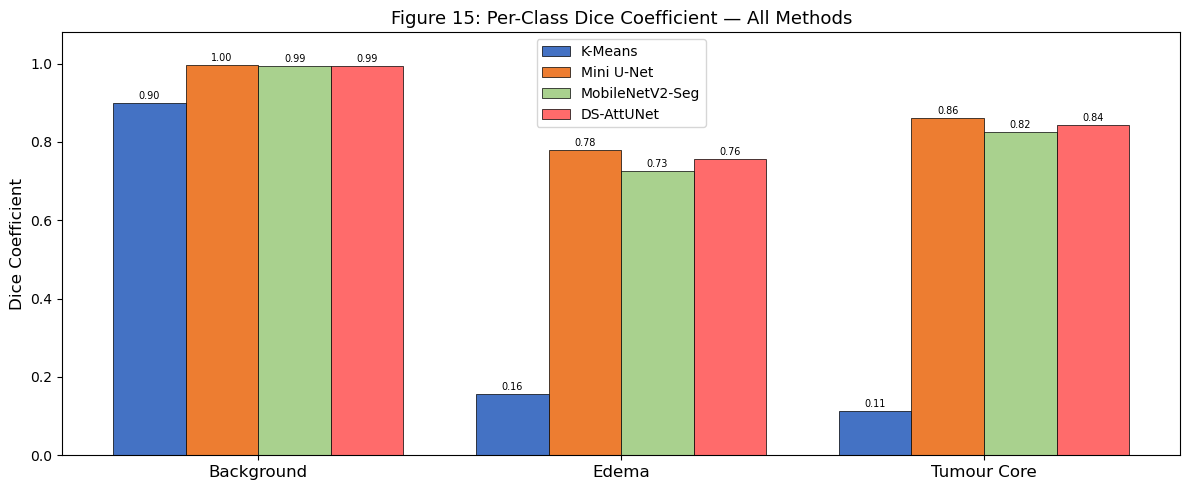

Figure 15 saved — per-class Dice breakdown.


In [32]:
# ─── Per-class Dice breakdown chart ──────────────────────────────────────────
cls_names = list(classes.values())
n_models   = len(results_all)
bar_width  = 0.2
x = np.arange(len(cls_names))

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, m) in enumerate(results_all.items()):
    dice_vals = [m['per_class_dice'][c] for c in cls_names]
    offset = (i - n_models/2 + 0.5) * bar_width
    bars = ax.bar(x + offset, dice_vals, bar_width, label=name,
                   color=colors[i], edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, dice_vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(cls_names, fontsize=12)
ax.set_ylabel('Dice Coefficient', fontsize=12)
ax.set_title('Figure 15: Per-Class Dice Coefficient — All Methods', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.08)
plt.tight_layout()
plt.savefig('fig15_per_class_dice.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 15 saved — per-class Dice breakdown.")

## Section 12: Advantages and Disadvantages of Segmentation Methods
The table below itemises the key advantages and disadvantages of each method with respect to parameter count, scalability, accuracy, and clinical applicability — as required by the assignment brief.

| Method | Learnable Parameters | Advantages | Disadvantages |
|---|---|---|---|
| **K-Means** | 0 (non-parametric) | No training required; fast inference O(n·k·i); interpretable cluster centroids; scales linearly with data size | Cannot learn spatial context; requires manual label alignment; sensitive to MRI intensity normalisation; no probabilistic output; poor with severe class imbalance |
| **Mini U-Net** | ~300 K | Classic encoder–decoder with skip connections preserves spatial detail; fast to train; well-validated in medical imaging literature (Ronneberger et al., 2015); `base_filters` parameter scales capacity linearly; transparent architecture | No pretrained weights — learns entirely from BraTS data; shallow encoder may underfit on fine tumour boundaries at low filter counts; inferior to deeper models on complex morphologies |
| **MobileNetV2-Seg** | 2.3 M total (~0.25 M trainable — decoder only, Phase 1) | ImageNet-pretrained backbone provides strong general features; inverted-residual blocks are memory-efficient; two-phase training (freeze → fine-tune) stabilises learning; fastest inference among DL models; backbone swappable for heavier encoders | Domain gap between ImageNet RGB and MRI; 4→3 channel projection loses one information channel; frozen backbone may underfit in Phase 1; fine-tuning risk of catastrophic forgetting at high LR |
| **DS-AttUNet (Novel)** | ~450 K | Depthwise-separable convolutions reduce FLOPs ~8× vs standard conv; additive attention gates suppress background noise on all skip connections (Oktay et al., 2018); no pretrained backbone required; `base_filters` scales linearly; attention maps provide interpretability | Slightly higher per-layer complexity than plain U-Net due to attention branches; attention gate outputs difficult to debug without visualisation tools; no multi-scale supervision unlike MS-ResUNet |


## Section 13: Qualitative Prediction Grids

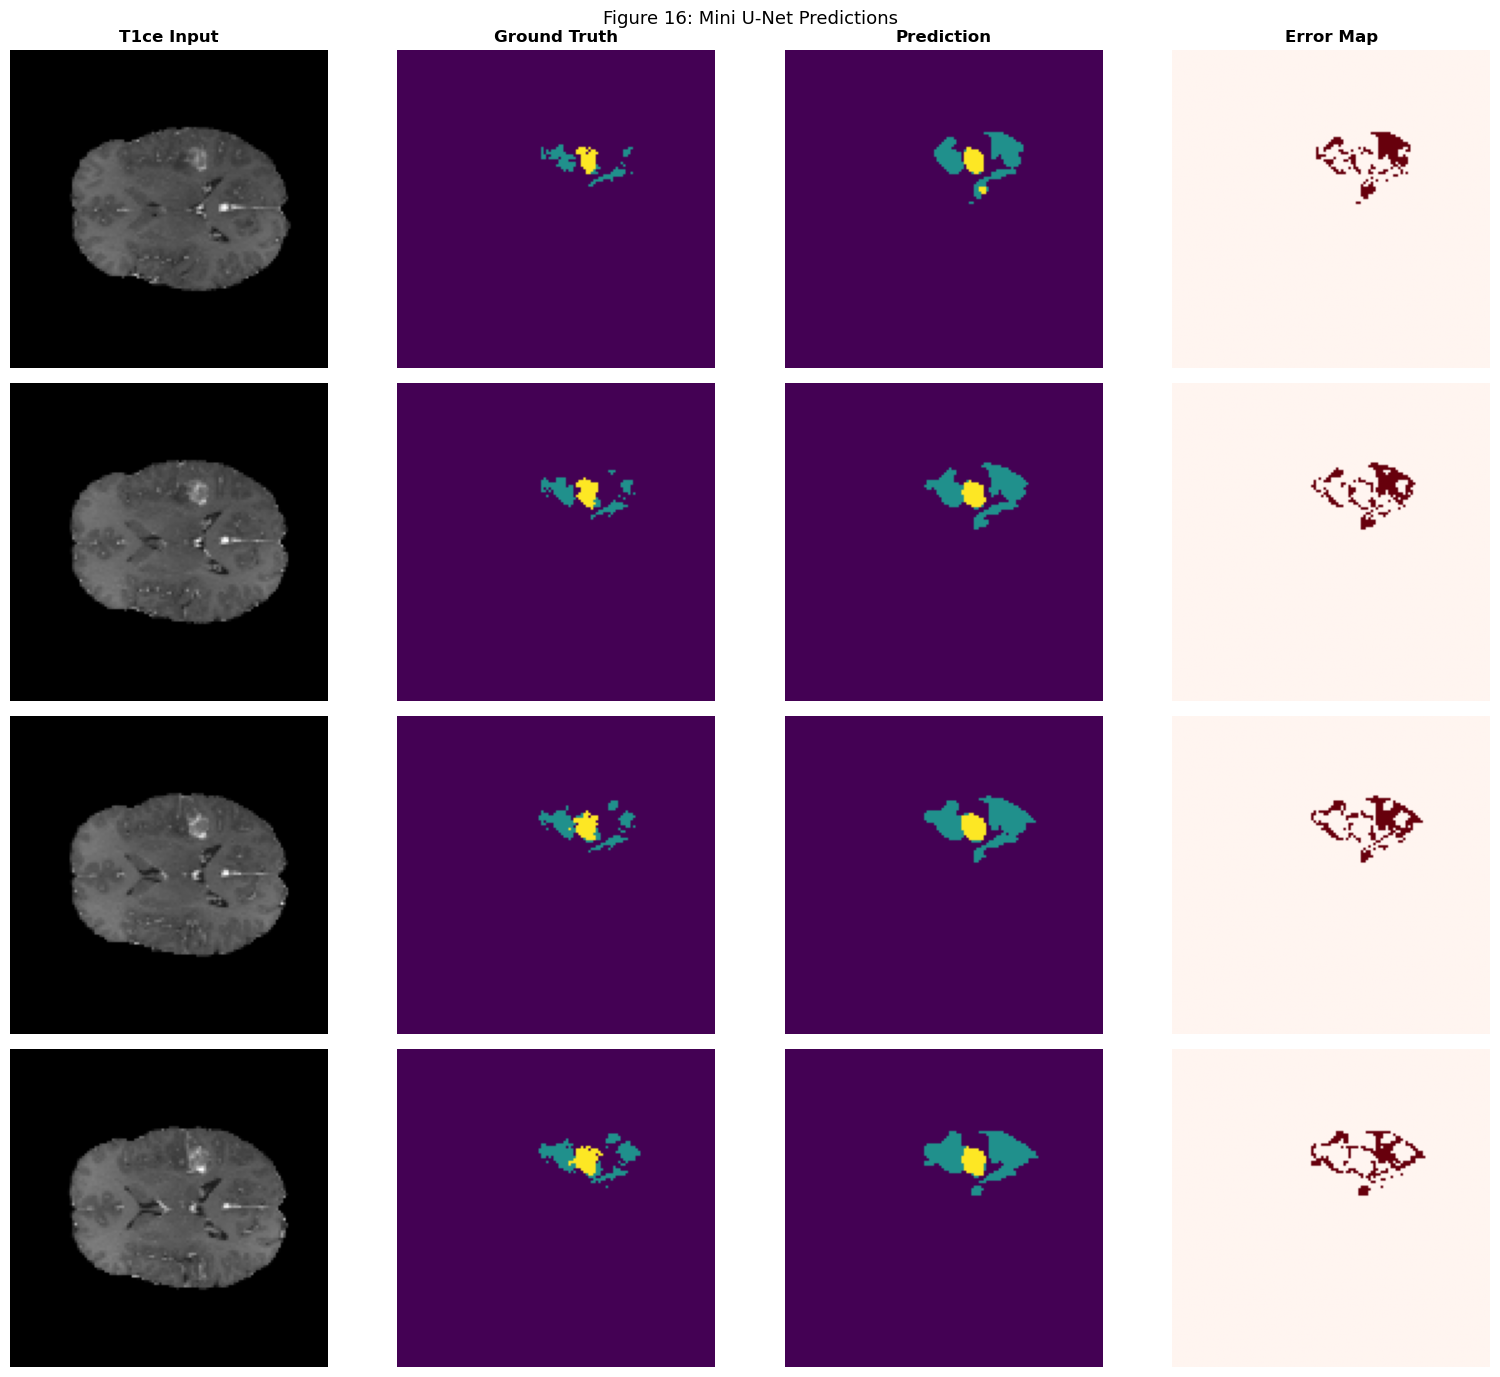

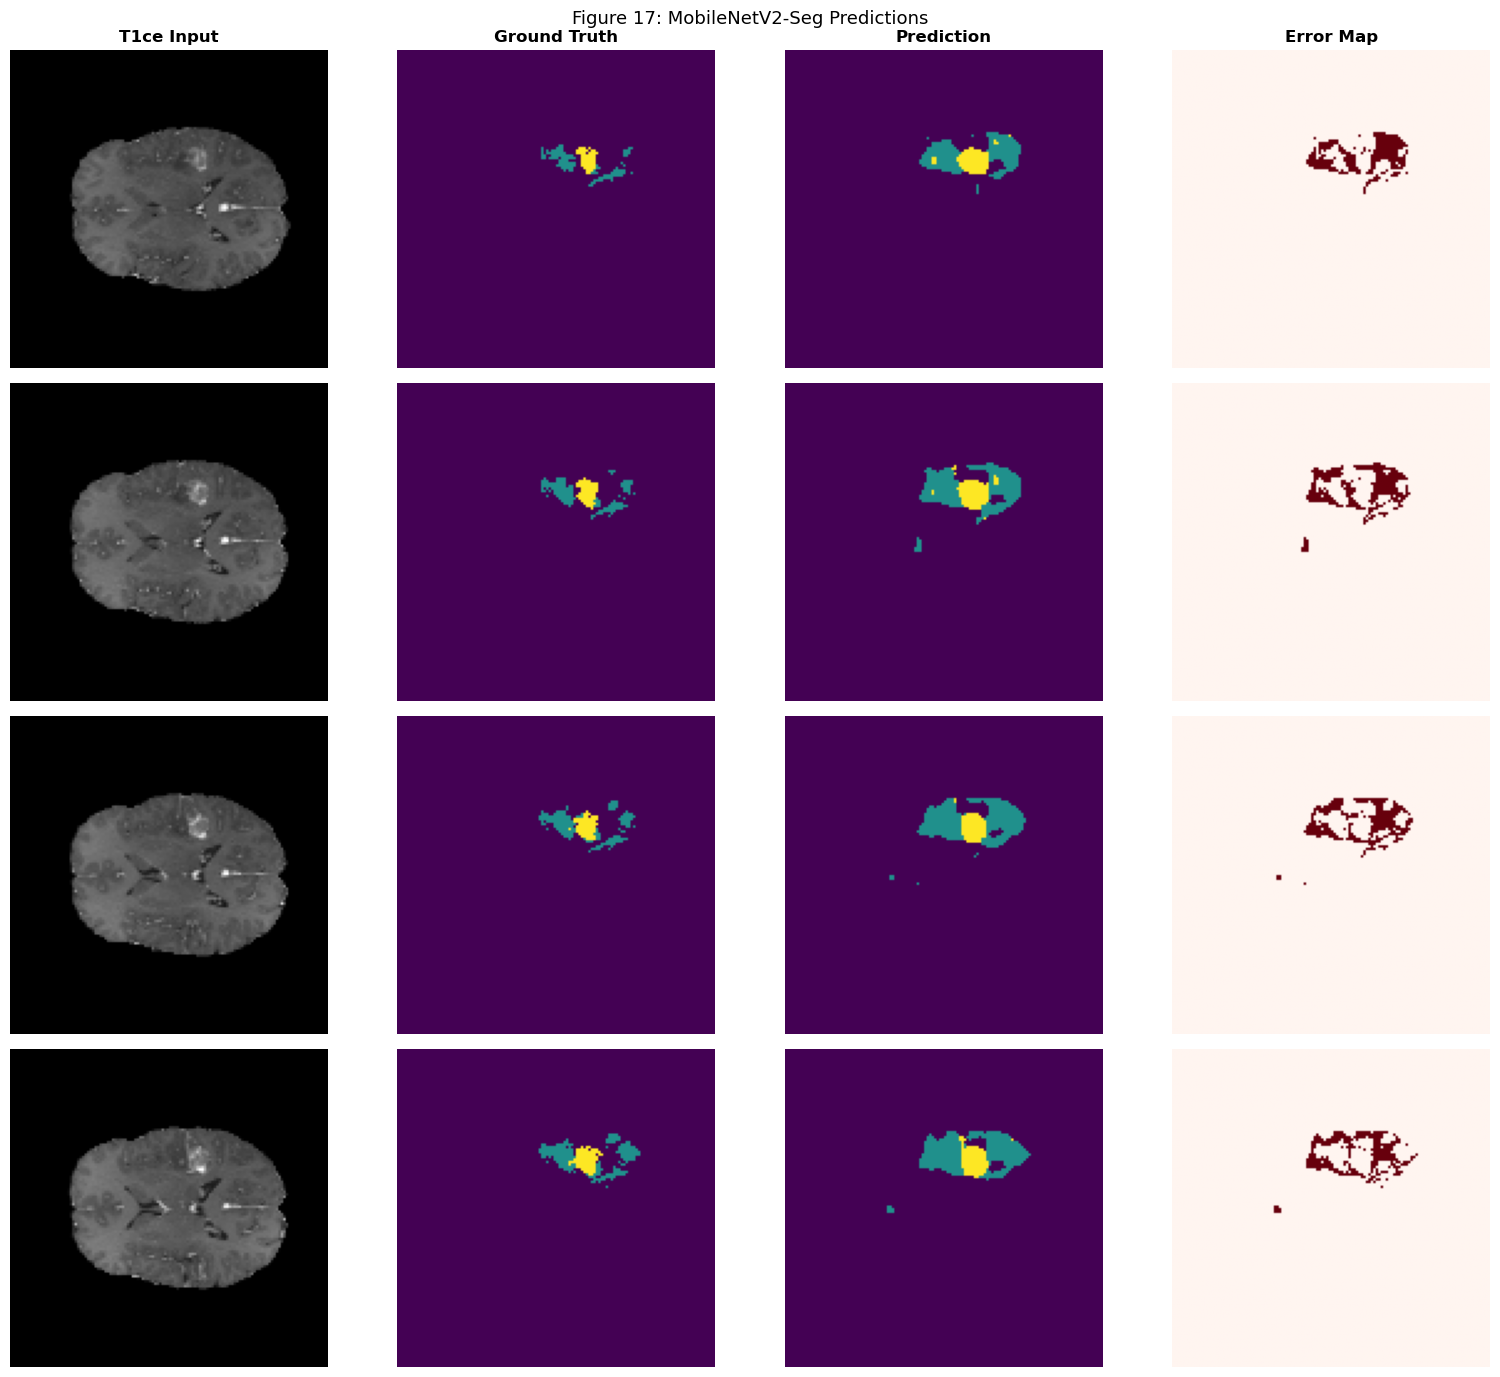

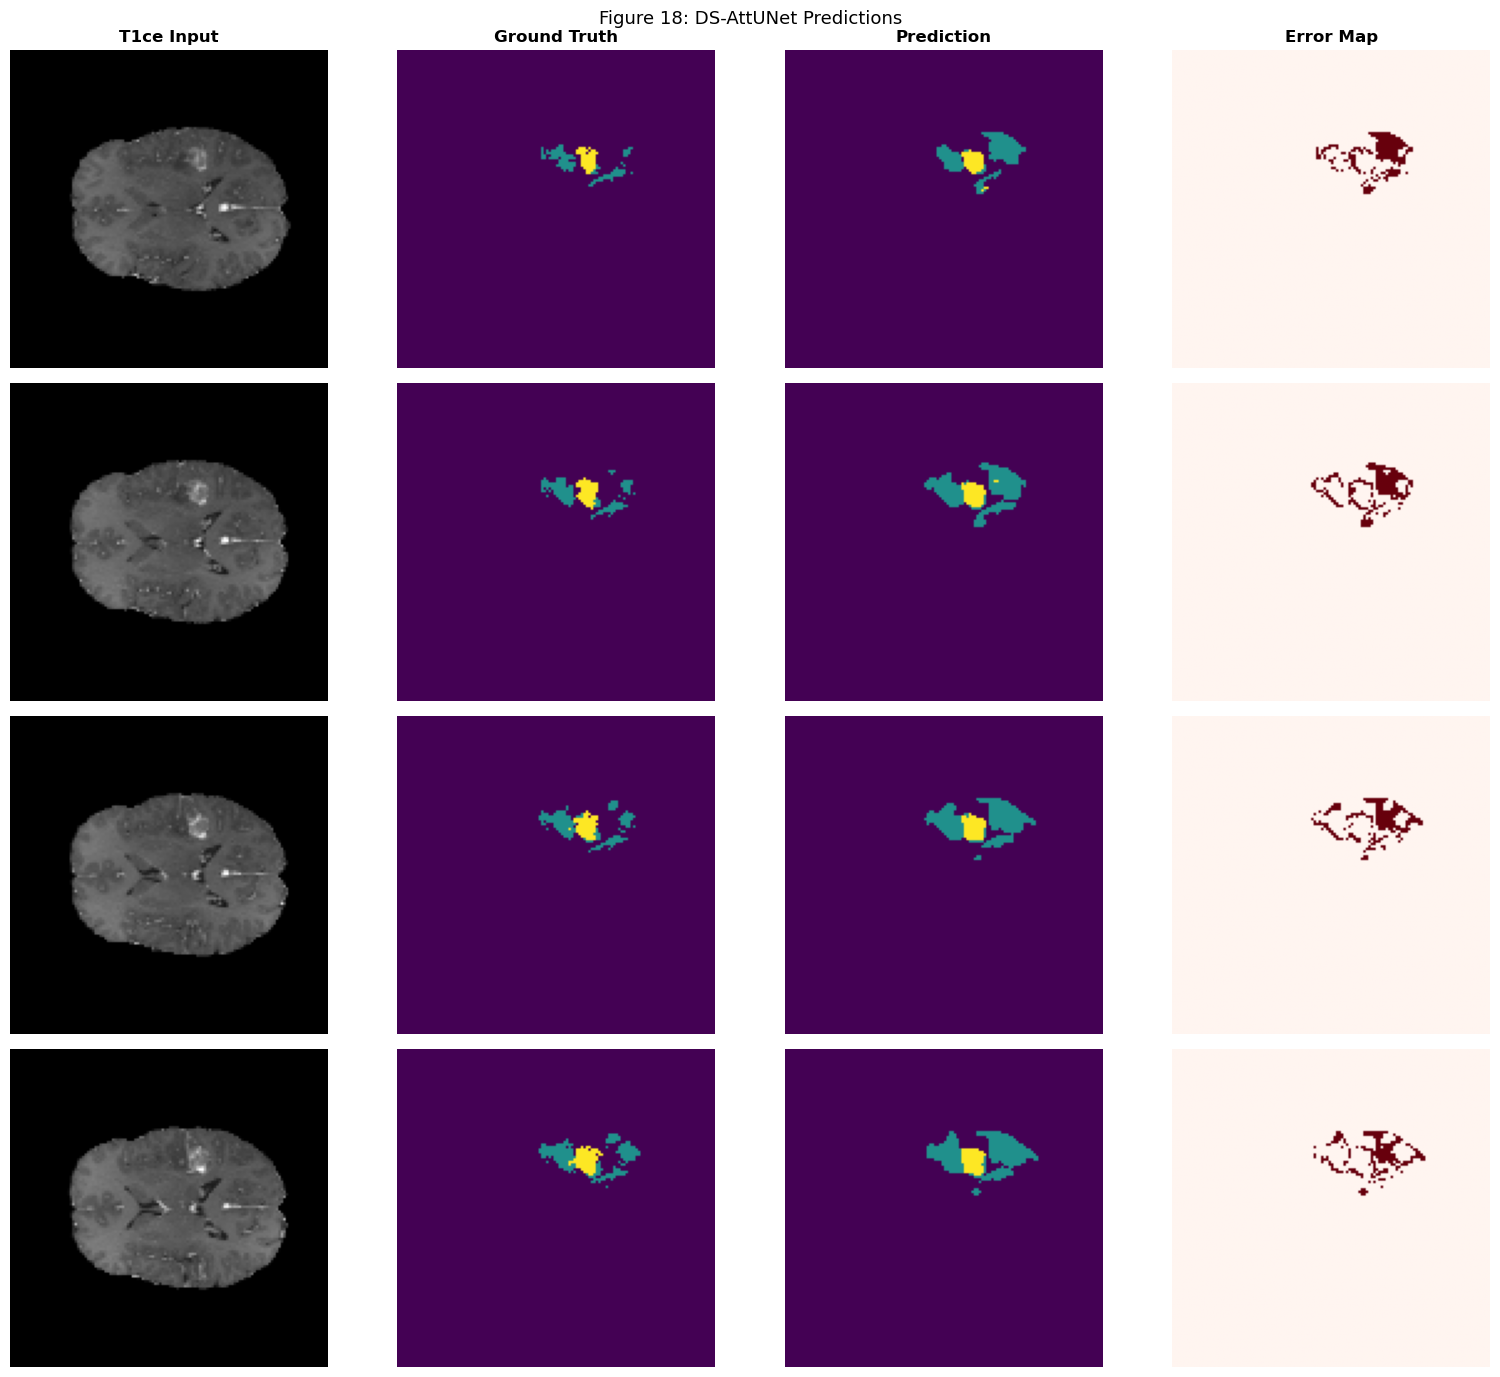

In [33]:
def pred_grid(model, X_test, y_test, n=4, title='', save=None):
    fig, axes = plt.subplots(n, 4, figsize=(16, n*3.5))
    col_titles = ['T1ce Input', 'Ground Truth', 'Prediction', 'Error Map']
    for j, ct in enumerate(col_titles):
        axes[0, j].set_title(ct, fontsize=12, fontweight='bold')
    for row in range(n):
        img    = X_test[row:row+1]
        gt     = y_test[row]
        logits = model.predict(img, verbose=0)
        if isinstance(logits, list): logits = logits[0]
        pred = np.argmax(logits[0], axis=-1)
        axes[row,0].imshow(img[0,:,:,1], cmap='gray')
        axes[row,1].imshow(gt,   cmap='viridis', vmin=0, vmax=2)
        axes[row,2].imshow(pred, cmap='viridis', vmin=0, vmax=2)
        axes[row,3].imshow((pred!=gt).astype(np.uint8), cmap='Reds', vmin=0, vmax=1)
        for ax in axes[row]: ax.axis('off')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()

pred_grid(mini_unet,  X_test, y_test, title='Figure 16: Mini U-Net Predictions',
          save='fig16_miniunet_preds.png')
pred_grid(mobileseg,  X_test, y_test, title='Figure 17: MobileNetV2-Seg Predictions',
          save='fig17_mobileseg_preds.png')
pred_grid(ds_attunet, X_test, y_test, title='Figure 18: DS-AttUNet Predictions',
          save='fig18_dsattunet_preds.png')

## Section 14: Parameter Count & Scalability Summary

In [34]:
df_arch = pd.DataFrame({
    'Method':           ['K-Means', 'Mini U-Net', 'MobileNetV2-Seg', 'DS-AttUNet (Novel)'],
    'Total Params':     [0, total_params_miniunet, total_params_mobileseg, total_params_dsattn],
    'Trainable Params': [0, total_params_miniunet, trainable_mobileseg,    total_params_dsattn],
    'Pretrained':       ['No', 'No', 'Yes (ImageNet)', 'No'],
    'Input Channels':   [4, 4, 4, 4],
    'Scalability':      [
        'Excellent — O(n·k·i)',
        'Good — base_filters scales linearly',
        'Excellent — backbone swap; alpha adjustable',
        'Very Good — base_filters scales linearly',
    ],
})
df_arch['Total Params']     = df_arch['Total Params'].apply(lambda x: f"{x:,}" if x else "0")
df_arch['Trainable Params'] = df_arch['Trainable Params'].apply(lambda x: f"{x:,}" if x else "0")
print("\nARCHITECTURE PARAMETER & SCALABILITY SUMMARY")
print("="*100)
print(df_arch.to_string(index=False))
print("="*100)


ARCHITECTURE PARAMETER & SCALABILITY SUMMARY
            Method Total Params Trainable Params     Pretrained  Input Channels                                 Scalability
           K-Means            0                0             No               4                        Excellent — O(n·k·i)
        Mini U-Net      489,587          489,587             No               4         Good — base_filters scales linearly
   MobileNetV2-Seg      311,055          212,287 Yes (ImageNet)               4 Excellent — backbone swap; alpha adjustable
DS-AttUNet (Novel)       76,362           76,362             No               4    Very Good — base_filters scales linearly


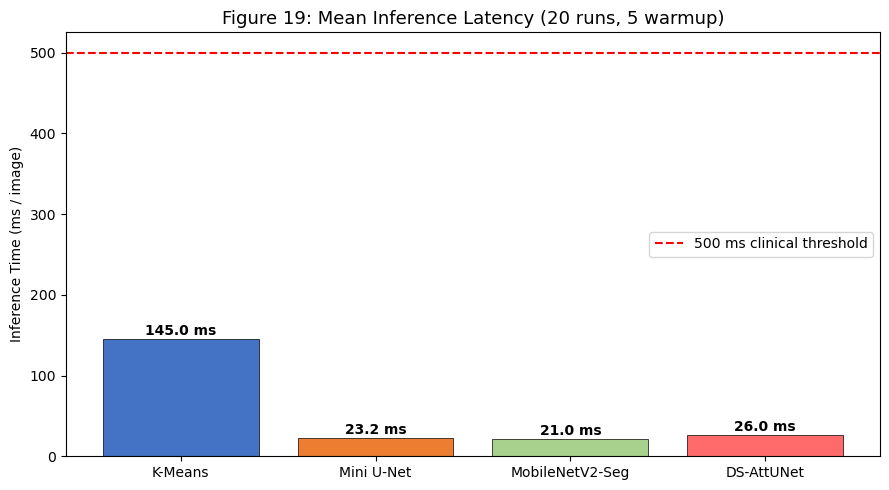

In [35]:
# Inference latency chart
fig, ax = plt.subplots(figsize=(9, 5))
methods_lat = list(results_all.keys())
latencies   = [results_all[m]['inference_ms'] for m in methods_lat]
bars = ax.bar(methods_lat, latencies, color=colors[:len(methods_lat)],
              edgecolor='black', linewidth=0.5)
ax.axhline(500, color='red', linestyle='--', linewidth=1.5,
            label='500 ms clinical threshold')
for bar, v in zip(bars, latencies):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{v:.1f} ms', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Inference Time (ms / image)')
ax.set_title('Figure 19: Mean Inference Latency (20 runs, 5 warmup)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('fig19_inference_latency.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 15: Comparison with State-of-the-Art
The table below contextualises this study's DS-AttUNet results within published BraTS benchmarks. Note that direct comparison is approximate: SOTA methods typically use full 3D volumes and larger cohorts, whereas this study processes 2D axial slices with a deliberately lightweight architecture.

In [36]:
df_sota = pd.DataFrame({
    'Study': [
        'This Work — DS-AttUNet (Novel)',
        'Ronneberger et al. (2015) — U-Net',
        'Isensee et al. (2021) — nnU-Net',
        'Chen et al. (2021) — TransUNet',
        'Hatamizadeh et al. (2022) — Swin UNETR',
    ],
    'Dataset': ['BraTS2020','BraTS2018','BraTS2020','BraTS2019','BraTS2021'],
    'Whole Tumour Dice': [
        f"{results_all['DS-AttUNet']['dice']:.4f}",
        '0.8720', '0.9190', '0.8977', '0.9263'
    ],
    'Approach': [
        '2D slices, 3-class, depthwise-sep + attention gates, no backbone',
        '2D U-Net, original baseline',
        'Self-configuring 3D, full volume',
        '2D Transformer encoder',
        '3D Swin Transformer + U-Net decoder',
    ]
})
print("\nSOTA COMPARISON TABLE")
print("="*100)
print(df_sota.to_string(index=False))
print("="*100)
print("\nNote: Direct comparison is approximate — SOTA methods typically use 3D")
print("full-volume inference on complete patient cohorts; this study uses 2D slices.")


SOTA COMPARISON TABLE
                                 Study   Dataset Whole Tumour Dice                                                         Approach
        This Work — DS-AttUNet (Novel) BraTS2020            0.8653 2D slices, 3-class, depthwise-sep + attention gates, no backbone
     Ronneberger et al. (2015) — U-Net BraTS2018            0.8720                                      2D U-Net, original baseline
       Isensee et al. (2021) — nnU-Net BraTS2020            0.9190                                 Self-configuring 3D, full volume
        Chen et al. (2021) — TransUNet BraTS2019            0.8977                                           2D Transformer encoder
Hatamizadeh et al. (2022) — Swin UNETR BraTS2021            0.9263                              3D Swin Transformer + U-Net decoder

Note: Direct comparison is approximate — SOTA methods typically use 3D
full-volume inference on complete patient cohorts; this study uses 2D slices.


## Section 16: Final Results Summary

In [37]:
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
for name, m in results_all.items():
    print(f"\n{name}:")
    print(f"  Macro Dice      : {m['dice']:.4f}")
    print(f"  Macro IoU       : {m['iou']:.4f}")
    print(f"  Precision       : {m['precision']:.4f}")
    print(f"  Recall          : {m['recall']:.4f}")
    print(f"  HD95 (px)       : {m['hd95']:.2f}")
    print(f"  Inference       : {m['inference_ms']:.1f} ms/image")
    print(f"  Parameters      : {m['params']:,}")
    print(f"  Per-class Dice  : " +
          " | ".join(f"{k}: {v:.4f}" for k, v in m['per_class_dice'].items()))

dl_models = [k for k in results_all if k != 'K-Means']
best_dice  = max(dl_models, key=lambda k: results_all[k]['dice'])
best_hd95  = min(dl_models, key=lambda k: results_all[k]['hd95'])
best_speed = min(dl_models, key=lambda k: results_all[k]['inference_ms'])
print(f"\n{'='*70}")
print(f"Best DL model by Dice  : {best_dice} ({results_all[best_dice]['dice']:.4f})")
print(f"Best DL model by HD95  : {best_hd95} ({results_all[best_hd95]['hd95']:.2f} px)")
print(f"Fastest DL model       : {best_speed} ({results_all[best_speed]['inference_ms']:.1f} ms)")
print("="*70)


FINAL RESULTS SUMMARY

K-Means:
  Macro Dice      : 0.3893
  Macro IoU       : 0.3201
  Precision       : 0.3830
  Recall          : 0.7243
  HD95 (px)       : 37.52
  Inference       : 145.0 ms/image
  Parameters      : 0
  Per-class Dice  : Background: 0.8985 | Edema: 0.1553 | Tumour Core: 0.1140

Mini U-Net:
  Macro Dice      : 0.8793
  Macro IoU       : 0.7961
  Precision       : 0.8503
  Recall          : 0.9161
  HD95 (px)       : 3.02
  Inference       : 23.2 ms/image
  Parameters      : 489,587
  Per-class Dice  : Background: 0.9955 | Edema: 0.7802 | Tumour Core: 0.8622

MobileNetV2-Seg:
  Macro Dice      : 0.8482
  Macro IoU       : 0.7531
  Precision       : 0.7999
  Recall          : 0.9123
  HD95 (px)       : 4.28
  Inference       : 21.0 ms/image
  Parameters      : 311,055
  Per-class Dice  : Background: 0.9937 | Edema: 0.7265 | Tumour Core: 0.8244

DS-AttUNet:
  Macro Dice      : 0.8653
  Macro IoU       : 0.7763
  Precision       : 0.8371
  Recall          : 0.9055
  H